In [2065]:
import ast
import os
import re
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.decomposition import PCA, FastICA
from sklearn.linear_model import LogisticRegression, Lasso
from sklearn.metrics import (
    roc_auc_score, accuracy_score, f1_score,
    average_precision_score, r2_score,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


## Utility helpers

In [2066]:
def load_tensor(path):
    assert os.path.exists(path), path
    return torch.load(path, map_location="cpu")

def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)

def calculate_auc(true_val, pred_val):
    """Compute AUC, flip direction if < 0.5."""
    auc = roc_auc_score(true_val, pred_val)
    if auc < 0.5:
        auc = 1 - auc
    return auc


## Config and path helpers

In [2067]:
def read_config_from_log(experiment_path):
    log_path = os.path.join(experiment_path, "log.txt")
    assert os.path.exists(log_path), log_path
    with open(log_path, "r") as f:
        first_line = f.readline().strip()
    return ast.literal_eval(first_line)


def get_data_dir_name_from_log(experiment_path):
    log_path = os.path.join(experiment_path, "log.txt")
    assert os.path.exists(log_path), log_path
    with open(log_path, "r") as f:
        for line in f:
            if line.startswith("data_dir:"):
                return os.path.basename(os.path.normpath(line.split("data_dir:", 1)[1].strip()))
            elif line.startswith("Loading existing synthetic dataset from"):
                
                return os.path.basename(os.path.normpath(line.split("Loading existing synthetic dataset from", 1)[1].strip()))
    raise ValueError(f"Could not find data_dir in {log_path}")


def infer_data_path(experiment_path):
    """Resolve absolute path to the saved dataset directory."""
    data_dir_name = get_data_dir_name_from_log(experiment_path)
    candidate = os.path.join("datasets", "multilabel_synthetic", data_dir_name)
    if os.path.exists(candidate):
        return candidate
    raise FileNotFoundError(f"Dataset not found at {candidate}")


def get_multilabel_config(experiment_path):
    """Return (num_concepts, num_residuals, num_hid_tasks, num_obs_tasks, hid_dim, obs_dim)."""
    cfg = read_config_from_log(experiment_path)
    d = cfg["data"]
    return (
        d["num_concepts"],
        d["num_residuals"],
        d.get("num_hid_tasks", 3),
        d.get("num_obs_tasks", 1),
        d["hid_dim"],
        d["obs_dim"],
    )


def print_data_info(experiment_path):
    data_path = infer_data_path(experiment_path)
    info = os.path.join(data_path, "info.txt")
    if os.path.exists(info):
        with open(info, "r") as f:
            print(f.read())


## Data loading

In [2068]:
def load_split(experiment_path, data_path, split: str,
               num_concepts: int, num_residuals: int):
    """
    Load one split worth of model outputs + dataset tensors.

    Model outputs (from experiment_path/<split>/):
        c_res_mu.pt                        — Gaussian mean of [concept, residual] logits
        concepts_residuals_pred_probs_mean — mean sigmoid probs over MC samples
        concepts_residuals_pred_probs_std  — std of sigmoid probs over MC samples
        concepts_residuals_sample_mean     — mean of hard Bernoulli samples

    Dataset tensors (from data_path/<split>/):
        x, concepts, residuals, y (multilabel),
        eta_concepts, eta_residuals,
        concept_signal, residual_signal,
        s_hid, s_obs,
        w_hid, w_obs, Sigma,
        hid_task_idx, obs_task_idx
    """
    model_split = os.path.join(experiment_path, split)
    data_split = os.path.join(data_path, split)

    if not os.path.exists(model_split):
        raise FileNotFoundError(
            f"Missing {model_split}. Run training with save_concept_and_residual_channel=True."
        )
    assert os.path.exists(data_split), data_split

    c_res_mu = load_tensor(os.path.join(model_split, "c_res_mu.pt"))
    cr_probs = load_tensor(os.path.join(model_split, "concepts_residuals_pred_probs_mean.pt"))
    cr_probs_std = load_tensor(os.path.join(model_split, "concepts_residuals_pred_probs_std.pt"))
    cr_sample = load_tensor(os.path.join(model_split, "concepts_residuals_sample_mean.pt"))
    


    out = {
        # ── model outputs ──────────────────────────────────────────────
        "c_mu": c_res_mu[:, :num_concepts],
        "res_mu": c_res_mu[:, num_concepts:],
        "concept_probs": cr_probs[:, :num_concepts],
        "residual_probs": cr_probs[:, num_concepts:],
        "concept_probs_std": cr_probs_std[:, :num_concepts],
        "residual_probs_std": cr_probs_std[:, num_concepts:],
        "concept_sample_mean": cr_sample[:, :num_concepts],
        "residual_sample_mean": cr_sample[:, num_concepts:],
        # ── dataset tensors ────────────────────────────────────────────
        "x": load_tensor(os.path.join(data_split, "x.pt")),
        "concepts": load_tensor(os.path.join(data_split, "concepts.pt")),
        "hidden_residuals": load_tensor(os.path.join(data_split, "residuals.pt")),
        "y": load_tensor(os.path.join(data_split, "y.pt")),  # (n, K+J)
        "eta_concepts": load_tensor(os.path.join(data_split, "eta_concepts.pt")),
        "eta_residuals": load_tensor(os.path.join(data_split, "eta_residuals.pt")),
        "concept_signal": load_tensor(os.path.join(data_split, "concept_signal.pt")),
        "hidden_residual_signal": load_tensor(os.path.join(data_split, "residual_signal.pt")),
        "s_hid": load_tensor(os.path.join(data_split, "s_hid.pt")),  # (n, K)
        "s_obs": load_tensor(os.path.join(data_split, "s_obs.pt")),  # (n, J)
        "w_hid": load_tensor(os.path.join(data_split, "w_hid.pt")),
        "w_obs": load_tensor(os.path.join(data_split, "w_obs.pt")),
        "hid_task_idx": load_tensor(os.path.join(data_split, "hid_task_idx.pt")),
        "obs_task_idx": load_tensor(os.path.join(data_split, "obs_task_idx.pt")),
        "avg_model_covariance_matrix": load_tensor(os.path.join(model_split, "avg_covariance_matrix.pt")) if os.path.exists(os.path.join(model_split, "avg_covariance_matrix.pt")) else None,
        "data_sigma_matrix": load_tensor(os.path.join(data_split, "Sigma.pt")) if os.path.exists(os.path.join(data_split, "Sigma.pt")) else None,
    }
    

    # Sanity: row counts must agree
    n_model = out["res_mu"].shape[0]
    n_data = out["hidden_residuals"].shape[0]
    assert n_model == n_data, (
        f"{split}: model has {n_model} rows but data has {n_data}. "
        "Residual dump likely used a shuffled/drop_last loader."
    )
    return out


## Specify experiment

In [2069]:

# updated alpha=1, beta=1, sigma_x = 0.01, standardize=True
# EXPERIMENT_PATH = os.path.join(
#     "experiments", "scbm_residual", "multilabel_synthetic",
#     "K_5_J_2_alpha_1.0_beta_1.0_rho_cr_0.0_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.01_standardize_True_num_res_20_2026-07-02_13-13-54_337de"
# )





# updated (save avg model covariance) alpha=1, beta=1, sigma_x = 0.5, standardize=True
# EXPERIMENT_PATH = os.path.join("experiments", "scbm_residual", "multilabel_synthetic",
#                                "K_5_J_2_alpha_1.0_beta_1.0_rho_cr_0.0_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.5_standardize_True_num_res_20_2026-07-02_13-13-54_c7cfa"
# )

# # alpha=1, beta=0, sigma_x = 0.01, standardize=True
# EXPERIMENT_PATH = os.path.join(
#     "experiments", "scbm_residual", "multilabel_synthetic",
#     "K_5_J_2_alpha_1.0_beta_0.0_rho_cr_0.0_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.01_standardize_True_num_res_20_2026-06-30_18-02-46_2214e"
# )


# alpha=1, beta=0, sigma_x = 0.5, standardize=True
# EXPERIMENT_PATH = os.path.join(
#     "experiments", "scbm_residual", "multilabel_synthetic",
#     "K_5_J_2_alpha_1.0_beta_0.0_rho_cr_0.0_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.5_standardize_True_num_res_20_2026-06-30_18-02-32_80deb"
# )




# alpha=1, beta=0.5, sigma_x = 0.01, standardize=True
EXPERIMENT_PATH = os.path.join(
    "experiments", "scbm_residual", "multilabel_synthetic",
    "K_5_J_2_alpha_1.0_beta_0.5_rho_cr_0.0_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.01_standardize_True_num_res_20_2026-06-30_18-02-43_18266"
)



# alpha=1, beta=1, sigma_x = 0.5, standardize=True, block_diagonal_cov = True
# EXPERIMENT_PATH = os.path.join(
#     "experiments", "scbm_residual", "multilabel_synthetic",
#     "K_5_J_2_alpha_1.0_beta_1.0_rho_cr_0.0_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.5_standardize_True_num_res_20_block_diagonal_cov_True_2026-07-01_17-38-56_0b96b"   
# )

# alpha=1, beta=1, sigma_x = 0.01, standardize=True, block_diagonal_cov = True
# EXPERIMENT_PATH = os.path.join(
#     "experiments", "scbm_residual", "multilabel_synthetic",
#     "K_5_J_2_alpha_1.0_beta_1.0_rho_cr_0.0_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.01_standardize_True_num_res_20_block_diagonal_cov_True_2026-07-01_17-38-56_d2b0a"
# )


# alpha=1, beta=1, sigma_x = 0.5, standardize=True, cr_rho=0.5
# EXPERIMENT_PATH = os.path.join(
#     "experiments", "scbm_residual", "multilabel_synthetic",
#     "K_5_J_2_alpha_1.0_beta_1.0_rho_cr_0.5_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.5_standardize_True_num_res_20_2026-07-05_17-40-22_25c96"
# )


# alpha=1, beta=1, sigma_x = 0.5, standardize=True, cr_rho=0.5, paired
# EXPERIMENT_PATH = os.path.join(
#     "experiments", "scbm_residual", "multilabel_synthetic",
#     "K_5_J_2_alpha_1.0_beta_1.0_rho_cr_0.5_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.5_standardize_True_paired_cov_num_res_20_2026-07-05_19-54-17_ab403"
# )

# alpha=1, beta=1, sigma_x = 0.01, standardize=True, cr_rho=0.5, paired
# EXPERIMENT_PATH = os.path.join(
#     "experiments", "scbm_residual", "multilabel_synthetic",
#     "K_5_J_2_alpha_1.0_beta_1.0_rho_cr_0.75_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.01_standardize_True_paired_cov_num_res_20_2026-07-05_19-54-17_3f73e"
# )




In [2070]:
assert os.path.exists(EXPERIMENT_PATH), EXPERIMENT_PATH

# Resolve dataset path and config
DATA_PATH = infer_data_path(EXPERIMENT_PATH)
(num_concepts, num_residuals,
 num_hid_tasks, num_obs_tasks,
 hid_dim, obs_dim) = get_multilabel_config(EXPERIMENT_PATH)
num_tasks = num_hid_tasks + num_obs_tasks

print(f"num_concepts : {num_concepts}")
print(f"num_residuals: {num_residuals}")
print(f"num_hid_tasks: {num_hid_tasks}  (K)")
print(f"num_obs_tasks: {num_obs_tasks}  (J)")
print(f"num_tasks    : {num_tasks}  (K+J)")
print(f"hid_dim      : {hid_dim}")
print(f"obs_dim      : {obs_dim}")
print()
print_data_info(EXPERIMENT_PATH)
print(f"Block diagonal covariance: {read_config_from_log(EXPERIMENT_PATH)['model'].get('block_diagonal_cov', False)}")


num_concepts : 10
num_residuals: 20
num_hid_tasks: 5  (K)
num_obs_tasks: 2  (J)
num_tasks    : 7  (K+J)
hid_dim      : 20
obs_dim      : 10

[multilabel synthetic dataset]
num_hid_tasks : 5
num_obs_tasks : 2
num_tasks/num_classes : 7
alpha : 1.0
beta : 0.5
hid_task_idx : [5, 14, 7, 2, 17]
obs_task_idx : [4, 7]
rho_cr : 0.0
rho_cc : 0.0
rho_rr : 0.0
task_sparsity_hid : 0.25
task_sparsity_obs : 0.3
sigma_x : 0.01
hid_dim : 20
obs_dim : 10
seed : 0
train / val / test : 30000 / 10000 / 10000
min_weight_ratio : 0.4
data created for model at: /cluster/home/smarcou/work/experiments_scbm/scbm_residual/multilabel_synthetic/K_5_J_2_alpha_1.0_beta_0.5_rho_cr_0.0_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.01_standardize_True_num_res_20_2026-06-30_18-02-43_18266
standardize : True

Block diagonal covariance: False


## Load data splits

In [2071]:
train_data = load_split(EXPERIMENT_PATH, DATA_PATH, "train",
                        num_concepts=num_concepts, num_residuals=num_residuals)
val_data = load_split(EXPERIMENT_PATH, DATA_PATH, "val",
                        num_concepts=num_concepts, num_residuals=num_residuals)
test_data = load_split(EXPERIMENT_PATH, DATA_PATH, "test",
                        num_concepts=num_concepts, num_residuals=num_residuals)
splits = {"train": train_data, "val": val_data, "test": test_data}

for split_name, data in splits.items():
    print(f"{split_name}:")
    for key in ["x", "res_mu", "hidden_residuals", "y", "s_hid", "s_obs"]:
        print(f"  {key:28s} {tuple(data[key].shape)}")

w_hid = train_data["w_hid"]
w_obs = train_data["w_obs"]
hid_task_idx = train_data["hid_task_idx"]  # (K,) — which hidden concepts are task bits
obs_task_idx = train_data["obs_task_idx"]  # (J,)


train:
  x                            (30000, 100)
  res_mu                       (30000, 20)
  hidden_residuals             (30000, 20)
  y                            (30000, 7)
  s_hid                        (30000, 5)
  s_obs                        (30000, 2)
val:
  x                            (10000, 100)
  res_mu                       (10000, 20)
  hidden_residuals             (10000, 20)
  y                            (10000, 7)
  s_hid                        (10000, 5)
  s_obs                        (10000, 2)
test:
  x                            (10000, 100)
  res_mu                       (10000, 20)
  hidden_residuals             (10000, 20)
  y                            (10000, 7)
  s_hid                        (10000, 5)
  s_obs                        (10000, 2)


## Task weights and task index mapping

In [2072]:
# Hidden task weights — sorted by abs magnitude
df_w_hid = pd.DataFrame({
    "hidden_concept_idx": np.arange(w_hid.shape[0]),
    "weight": to_numpy(w_hid),
    "abs_weight": to_numpy(w_hid.abs()),
    "is_task_bit": [i in hid_task_idx.tolist() for i in range(w_hid.shape[0])],
})
df_w_hid = df_w_hid[df_w_hid["abs_weight"] > 1e-8].sort_values("abs_weight", ascending=False)

# Annotate which subtask index each hidden concept maps to
task_map_hid = {int(idx): k for k, idx in enumerate(hid_task_idx.tolist())}
print(f"task_map_hid: {task_map_hid}")
df_w_hid["hid_task_k"] = df_w_hid["hidden_concept_idx"].map(task_map_hid)

print("Hidden concept weights (K task bits highlighted):")
display(df_w_hid)

# Observed task weights
df_w_obs = pd.DataFrame({
    "observed_concept_idx": np.arange(w_obs.shape[0]),
    "weight": to_numpy(w_obs),
    "abs_weight": to_numpy(w_obs.abs()),
    "is_task_bit": [i in obs_task_idx.tolist() for i in range(w_obs.shape[0])],
})
df_w_obs = df_w_obs[df_w_obs["abs_weight"] > 1e-8].sort_values("abs_weight", ascending=False)

task_map_obs = {int(idx): j for j, idx in enumerate(obs_task_idx.tolist())}
print(f"task_map_obs: {task_map_obs}")
df_w_obs["obs_task_j"] = df_w_obs["observed_concept_idx"].map(task_map_obs)

print("\nObserved concept weights (J task bits highlighted):")
display(df_w_obs)


task_map_hid: {5: 0, 14: 1, 7: 2, 2: 3, 17: 4}
Hidden concept weights (K task bits highlighted):


,hidden_concept_idx,weight,abs_weight,is_task_bit,hid_task_k
5,5,0.974940,0.974940,True,0
14,14,-0.952066,0.952066,True,1
7,7,0.891934,0.891934,True,2
2,2,-0.609588,0.609588,True,3
17,17,0.549488,0.549488,True,4


task_map_obs: {4: 0, 7: 1}

Observed concept weights (J task bits highlighted):


,observed_concept_idx,weight,abs_weight,is_task_bit,obs_task_j
4,4,0.930378,0.930378,True,0.0
7,7,0.841165,0.841165,True,1.0
1,1,0.621388,0.621388,False,NaN


## Plot dataset balance

In [2073]:
for split_name, data in splits.items():
    y = data["y"]
    label_ratio = y.mean(dim=0).detach().cpu().numpy()
    col = ["label ratio"] + [f"task {k}" for k in range(num_tasks)]
    df_label_ratio = pd.DataFrame({
        "task_idx": np.arange(num_tasks),
        "label_ratio": label_ratio,
    })
    print(f"{split_name}")
    display(df_label_ratio)
    

train


,task_idx,label_ratio
0,0,0.499133
1,1,0.498567
2,2,0.499267
3,3,0.501533
4,4,0.500000
5,5,0.498500
6,6,0.498267


val


,task_idx,label_ratio
0,0,0.4956
1,1,0.4987
2,2,0.4927
3,3,0.4957
4,4,0.4941
5,5,0.4959
6,6,0.4980


test


,task_idx,label_ratio
0,0,0.5070
1,1,0.5056
2,2,0.5095
3,3,0.4997
4,4,0.5059
5,5,0.5086
6,6,0.5072


## Data covariance

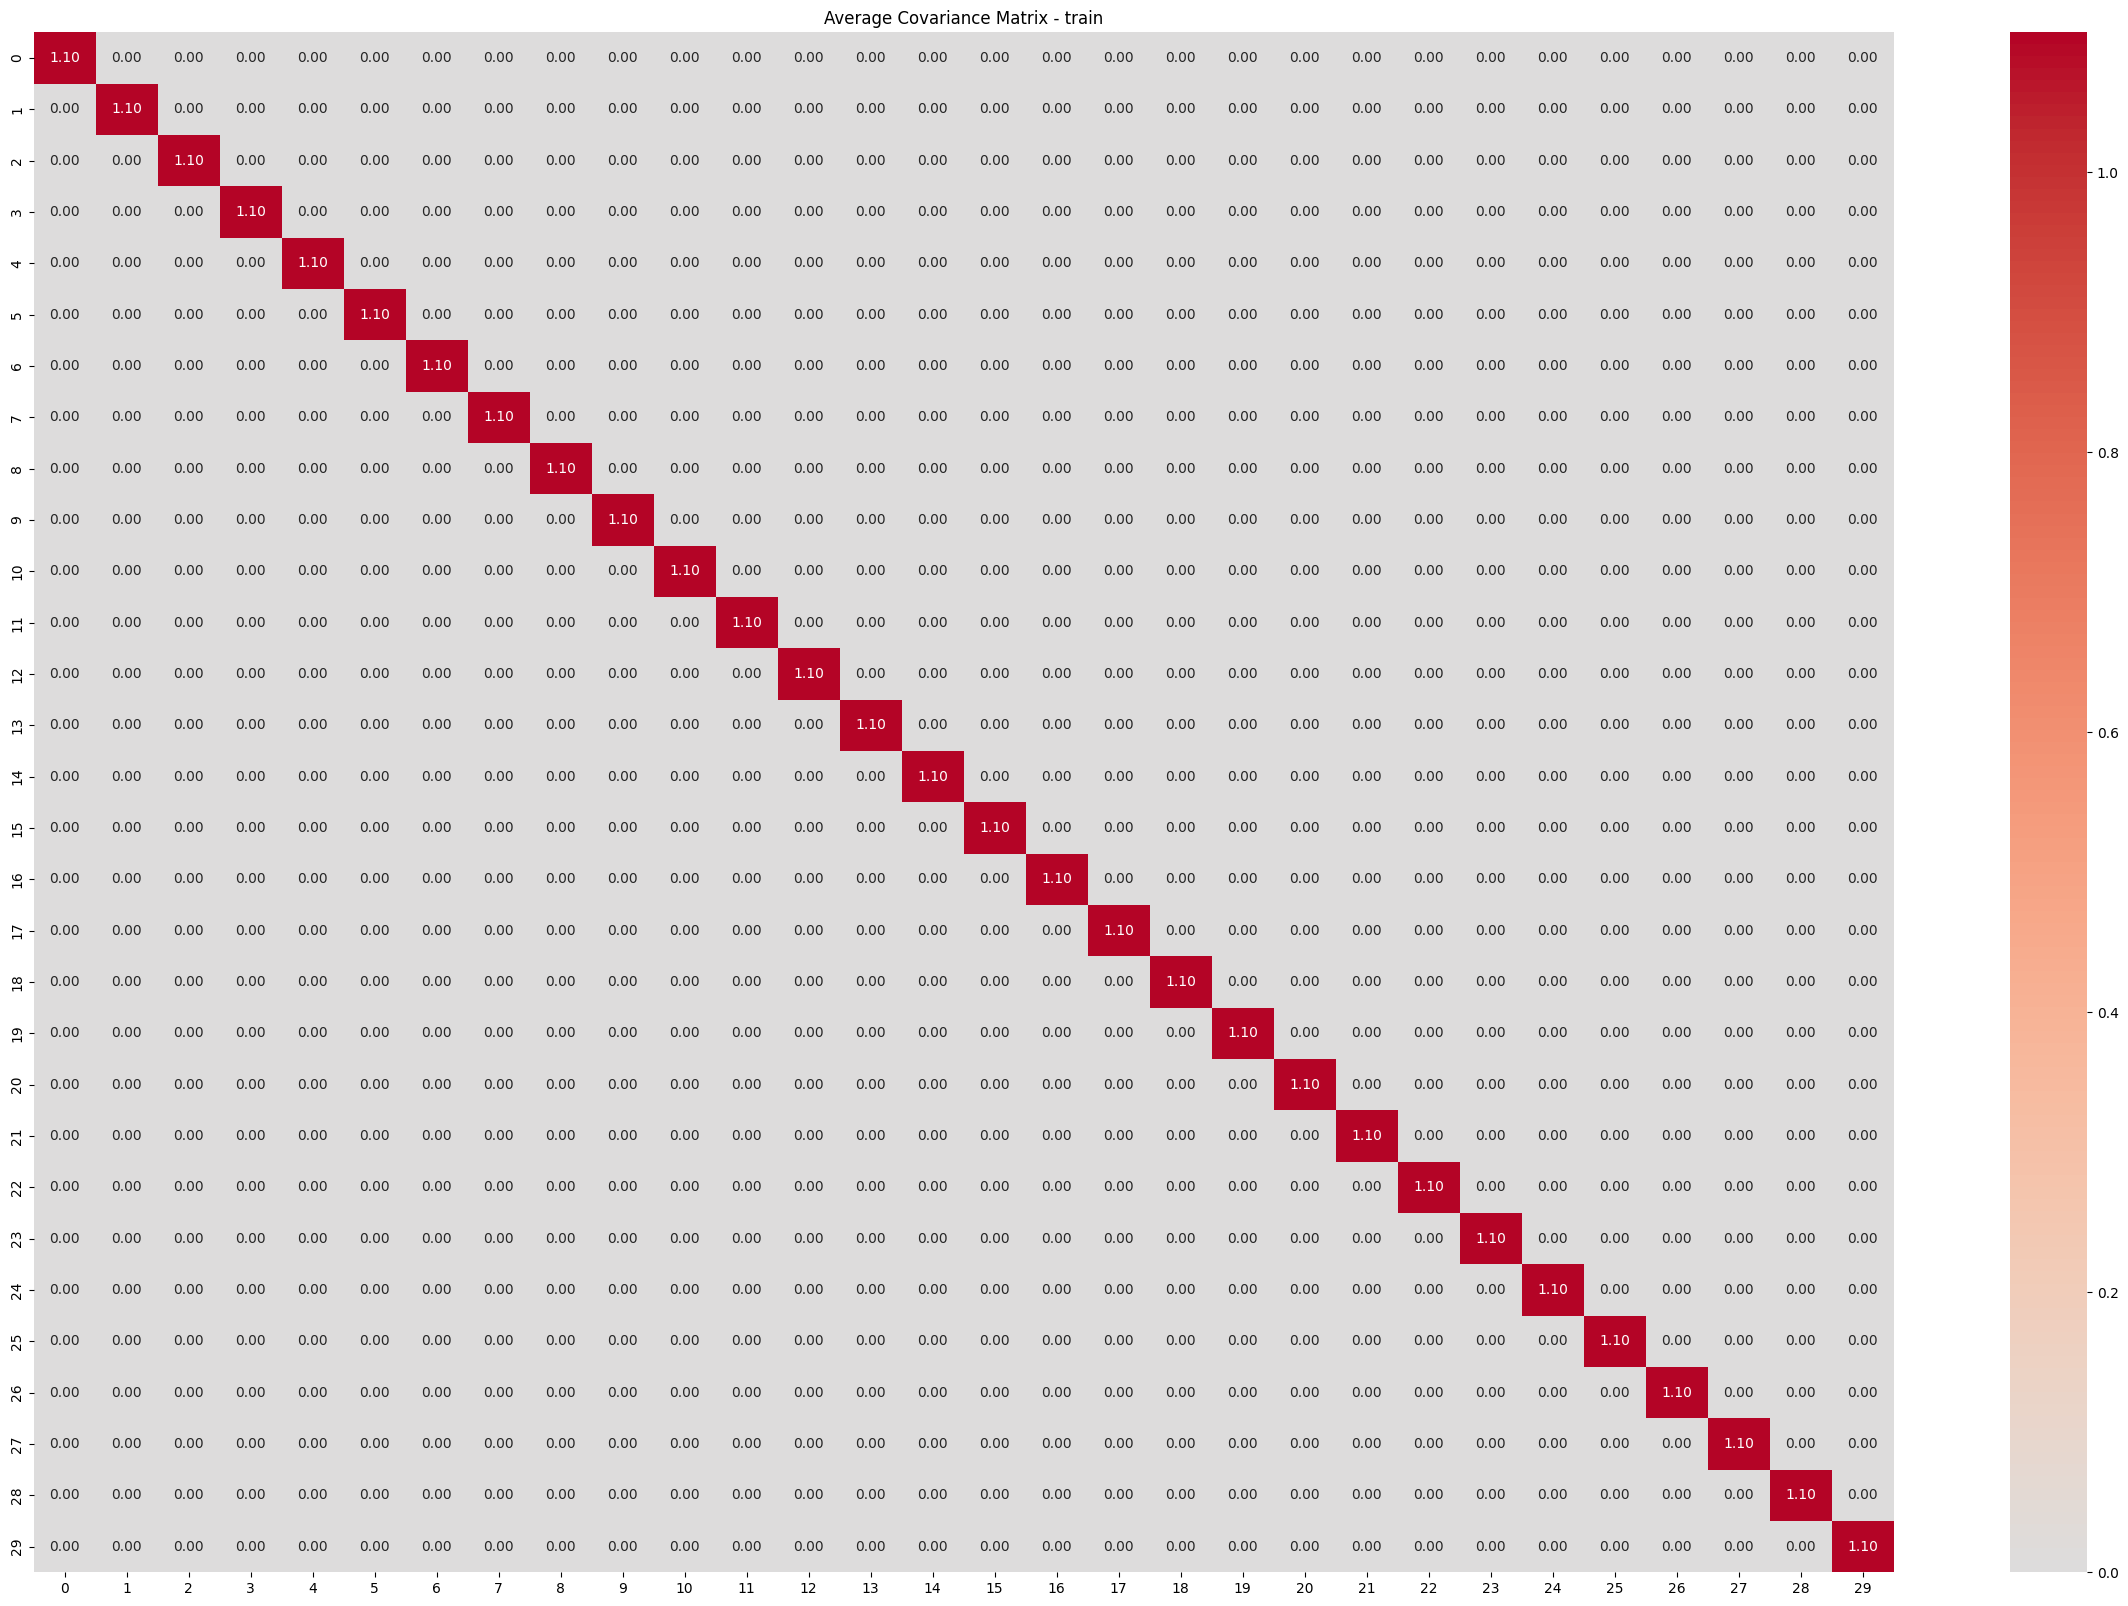

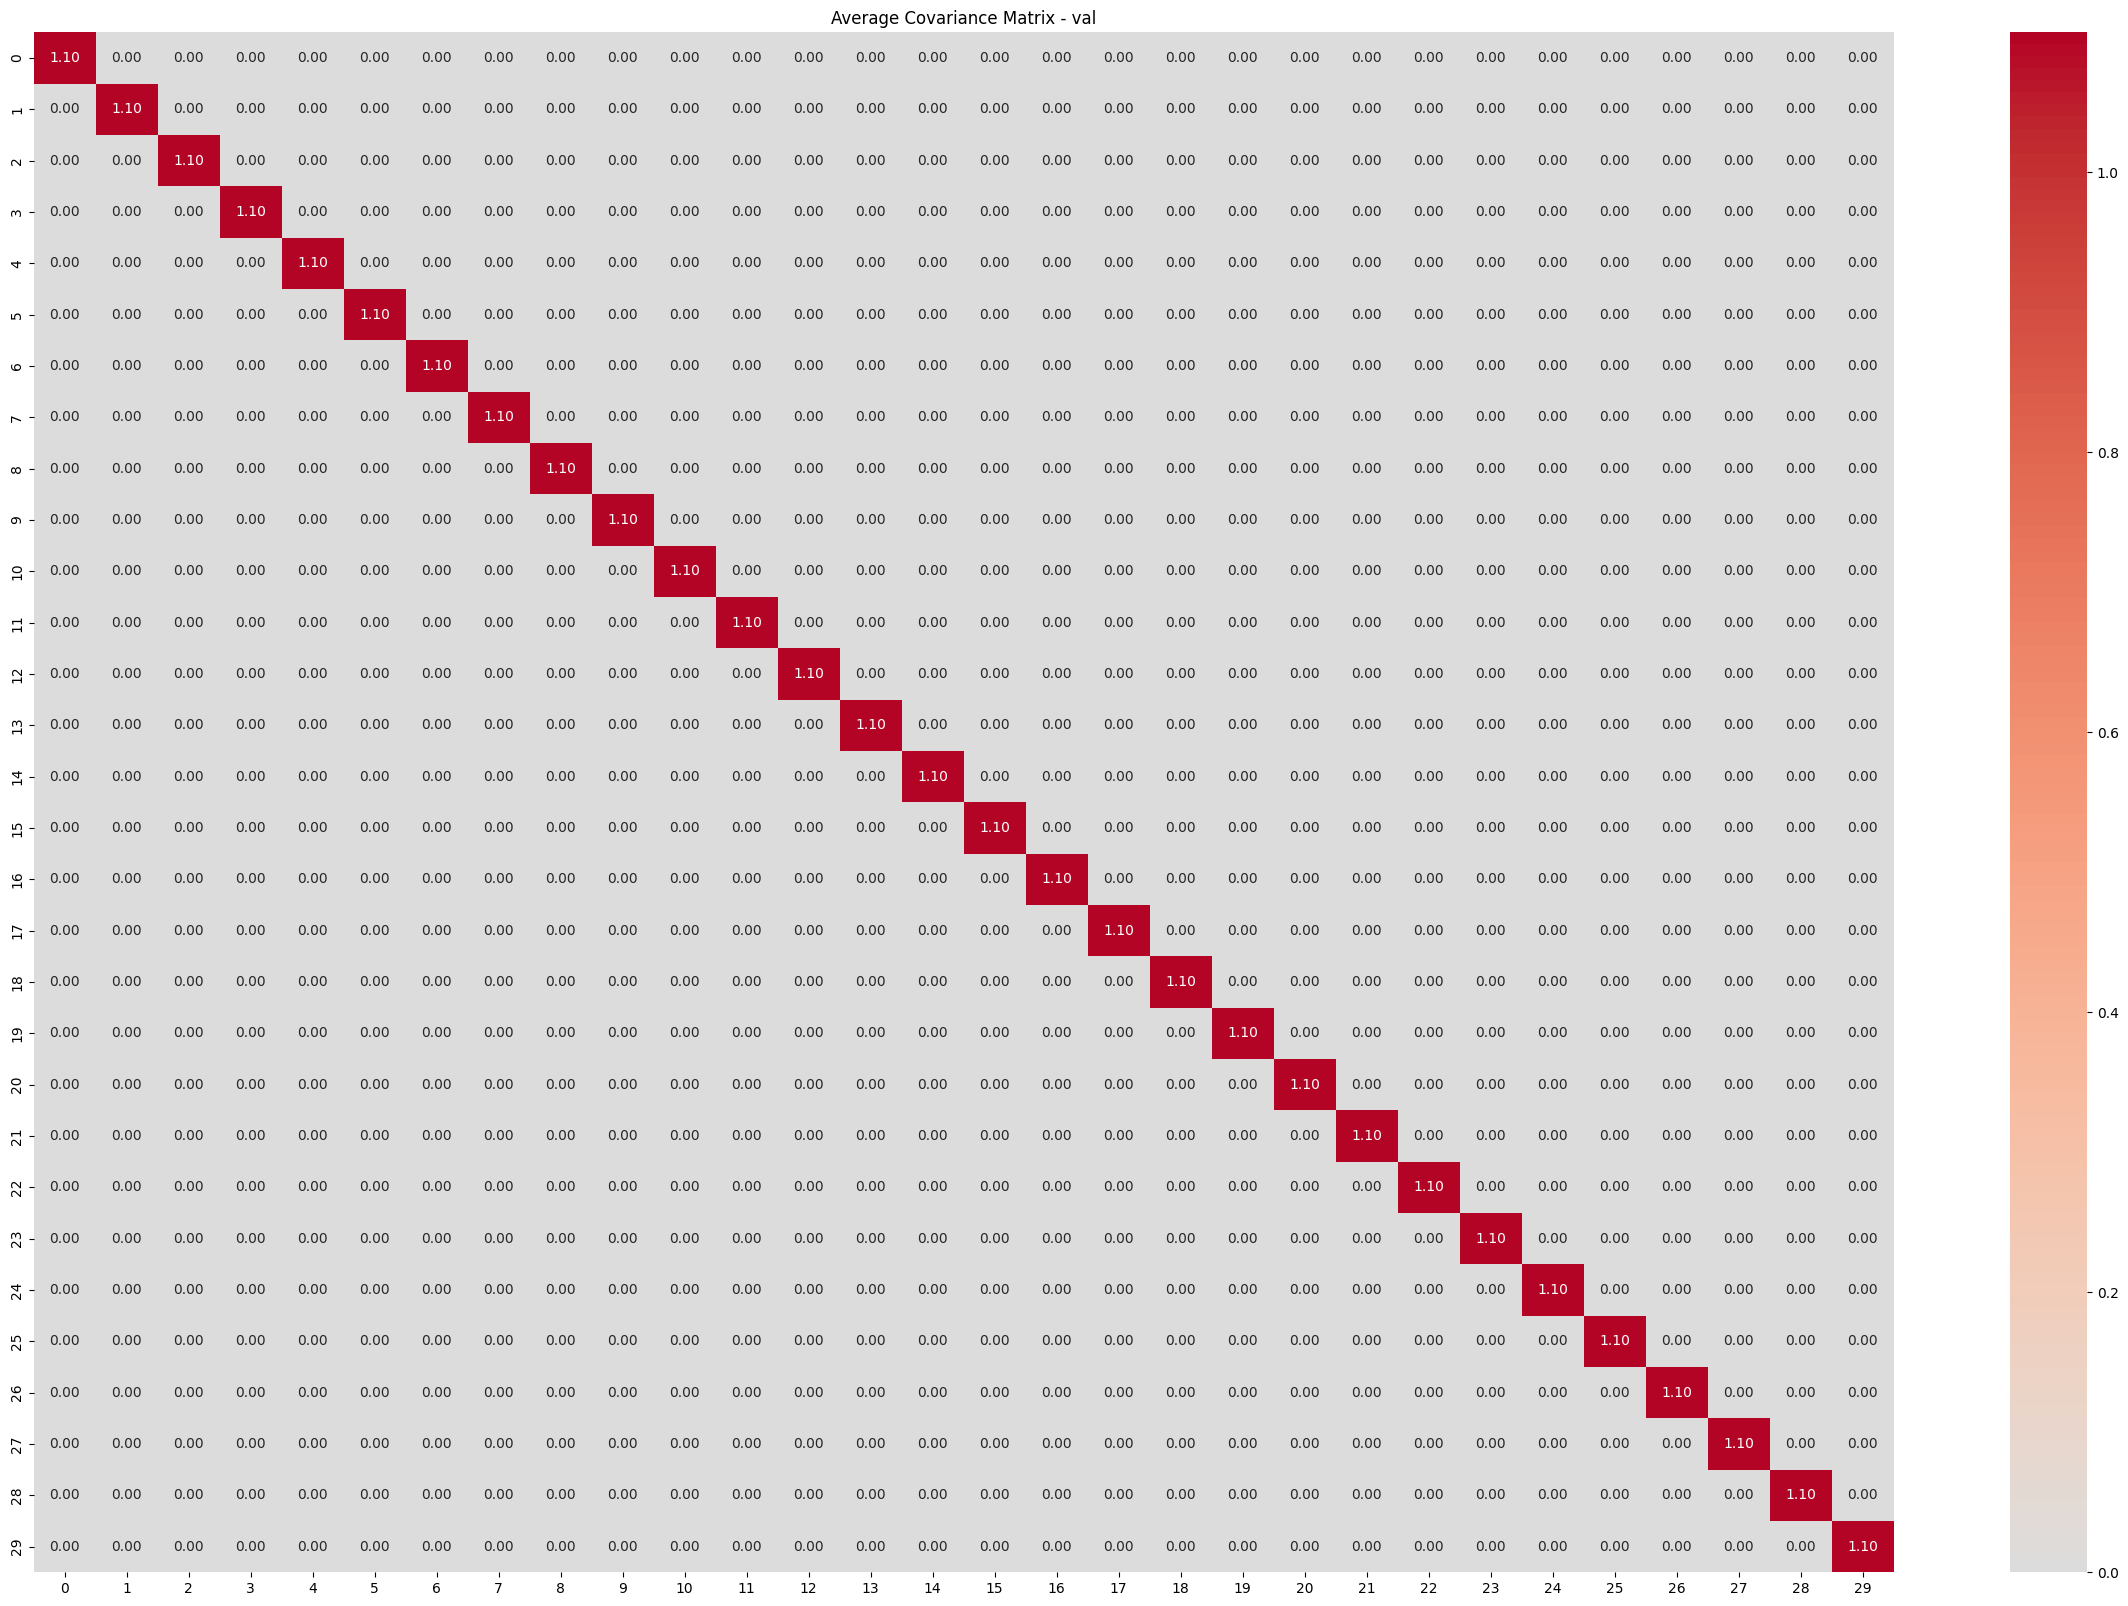

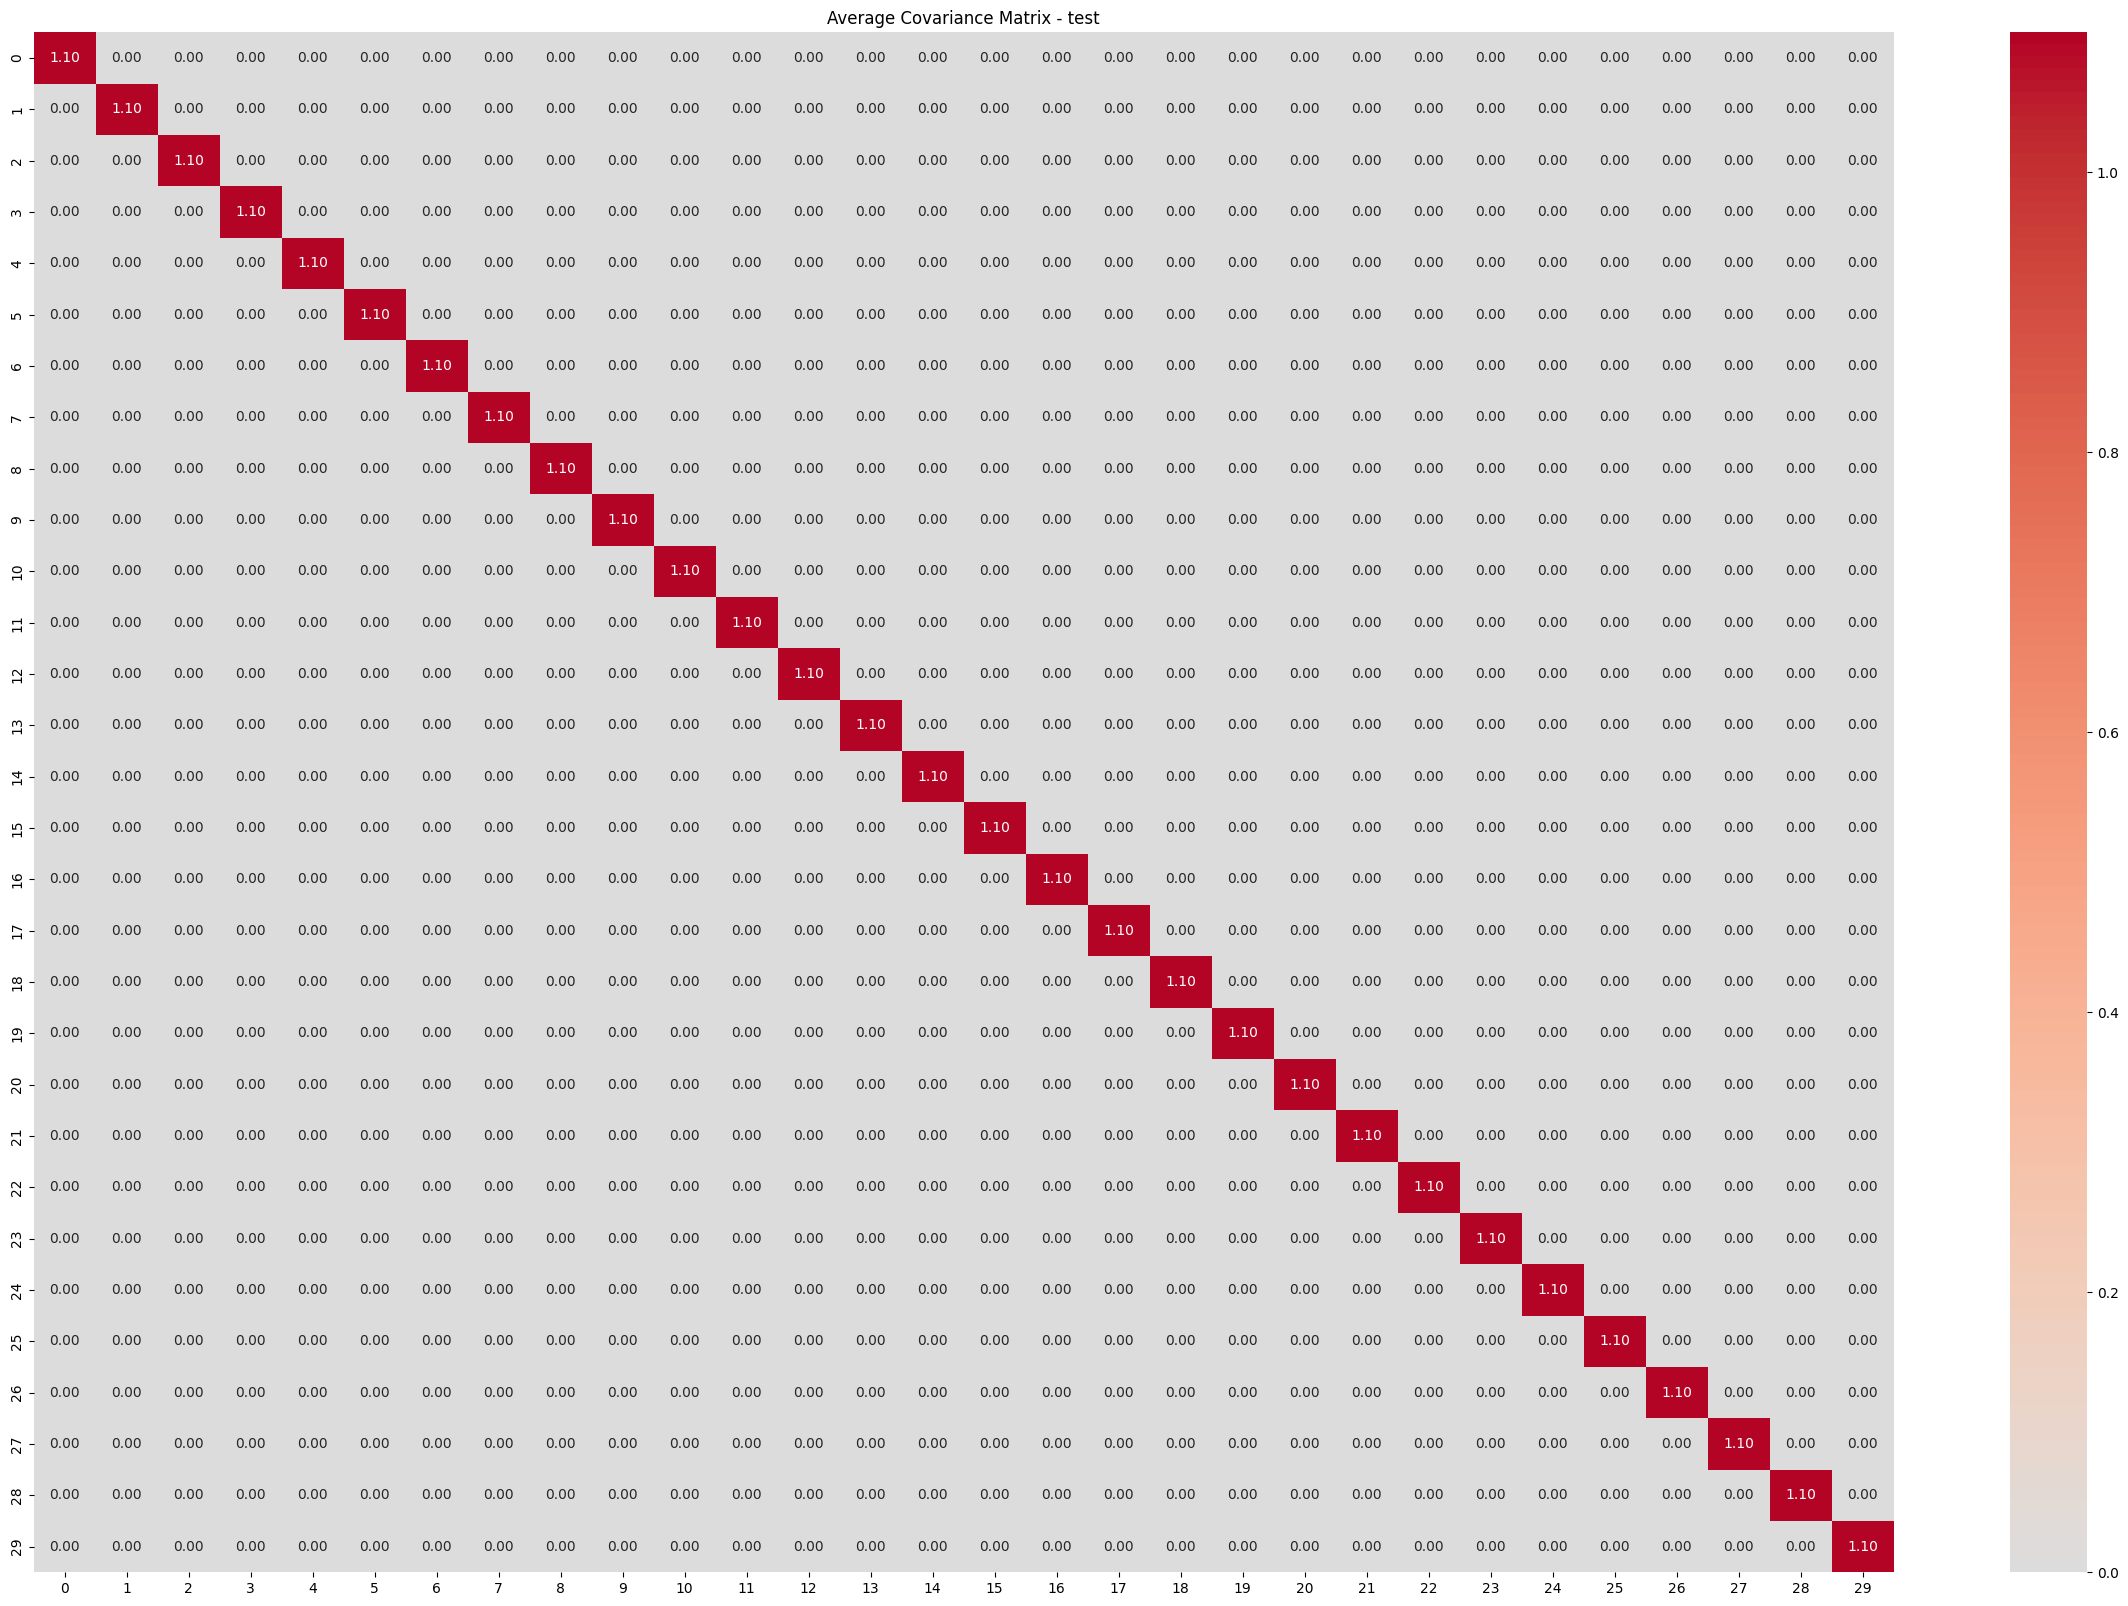

In [2074]:
for split_name, data in splits.items():
    avg_cov = data["data_sigma_matrix"]
    if avg_cov is not None:
        plt.figure(figsize=(30, 20))
        sns.heatmap(avg_cov, annot=True, fmt=".2f", cmap="coolwarm", center=0)
        plt.title(f"Average Covariance Matrix - {split_name}")
        plt.show()
        
        


## Model covariance

In [2075]:
for split_name, data in splits.items():
    avg_cov = data["avg_model_covariance_matrix"]
    if avg_cov is not None:
        plt.figure(figsize=(30, 20))
        sns.heatmap(avg_cov, annot=True, fmt=".2f", cmap="coolwarm", center=0)
        plt.title(f"Average Covariance Matrix - {split_name}")
        plt.show()
        
        

        

## Model performance — test set metrics

In [2076]:
def parse_test_metrics_multilabel(experiment_path, num_tasks: int):
    """
    Parse multilabel metrics from the last 'Test' line in log.txt.
    Returns a dict with macro_auroc, hamming_accuracy, exact_match,
    per-task auroc/ap, concept metrics.
    """
    log_path = os.path.join(experiment_path, "log.txt")
    test_line = None
    with open(log_path, "r") as f:
        for line in f:
            if "Test" in line:
                test_line = line
    if test_line is None:
        raise ValueError("No 'Test' line found in log.txt")

    def get_metric(pattern, line, default=None):
        m = re.search(pattern, line)
        return float(m.group(1)) if m else default

    metrics = {
        "y_macro_auroc": get_metric(r"y_macro_auroc:\s*([0-9.]+)", test_line),
        "y_macro_ap": get_metric(r"y_macro_ap:\s*([0-9.]+)", test_line),
        "y_hamming_accuracy": get_metric(r"y_hamming_accuracy:\s*([0-9.]+)", test_line),
        "y_exact_match": get_metric(r"y_exact_match:\s*([0-9.]+)", test_line),
        "c_accuracy": get_metric(r"c_accuracy:\s*([0-9.]+)", test_line),
        "c_AUROC": get_metric(r"c_AUROC:\s*([0-9.]+)", test_line),
    }
    for k in range(num_tasks):
        metrics[f"y_auroc_task_{k}"] = get_metric(rf"y_auroc_task_{k}:\s*([0-9.]+)", test_line)
        metrics[f"y_accuracy_task_{k}"] = get_metric(rf"y_accuracy_task_{k}:\s*([0-9.]+)", test_line)
        metrics[f"y_ap_task_{k}"] = get_metric(rf"y_ap_task_{k}:\s*([0-9.]+)", test_line)
    return metrics

test_metrics = parse_test_metrics_multilabel(EXPERIMENT_PATH, num_tasks)

# Display summary
summary_df = pd.DataFrame([test_metrics])
display(summary_df[[c for c in summary_df.columns if "task" not in c]])

# Per-task AUROC bar chart
def plot_per_task_metric(
    metrics,
    metric_name="y_accuracy_task",
    ylabel=None,
    title=None,
    ylim=(0.4, 1.05),
):
    task_values = [metrics.get(f"{metric_name}_{k}") for k in range(num_tasks)]

    # Use 0 for missing values so no visible bar is plotted
    plot_values = [0.0 if v is None else v for v in task_values]

    task_labels = (
        [f"hid_task_{k}\n(h{hid_task_idx[k].item()})" for k in range(num_hid_tasks)]
        + [f"obs_task_{j}\n(c{obs_task_idx[j].item()})" for j in range(num_obs_tasks)]
    )
    colors = ["steelblue"] * num_hid_tasks + ["coral"] * num_obs_tasks

    display_name = {
        "y_accuracy_task": "Accuracy",
        "y_auroc_task": "AUROC",
        "y_ap_task": "Average Precision",
    }.get(metric_name, metric_name)

    fig, ax = plt.subplots(figsize=(max(6, num_tasks * 1.2), 4))
    bars = ax.bar(task_labels, plot_values, color=colors)

    ax.set_ylim(*ylim)
    ax.set_ylabel(ylabel or display_name)
    ax.set_title(title or f"Per-task {display_name} (blue=hidden tasks, coral=observed tasks)")

    for bar, v in zip(bars, task_values):
        if v is None:
            label = "nan"
            y_pos = ylim[0] + 0.005
        else:
            label = f"{v:.3f}"
            y_pos = bar.get_height() + 0.005

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            y_pos,
            label,
            ha="center",
            va="bottom",
            fontsize=9,
        )

    plt.tight_layout()
    plt.show()

,y_macro_auroc,y_macro_ap,y_hamming_accuracy,y_exact_match,c_accuracy,c_AUROC
0,0.984,0.985,0.931,0.644,0.934,0.969


,y_macro_auroc,y_macro_ap,y_hamming_accuracy,y_exact_match,c_accuracy,c_AUROC
0,0.984,0.985,0.931,0.644,0.934,0.969


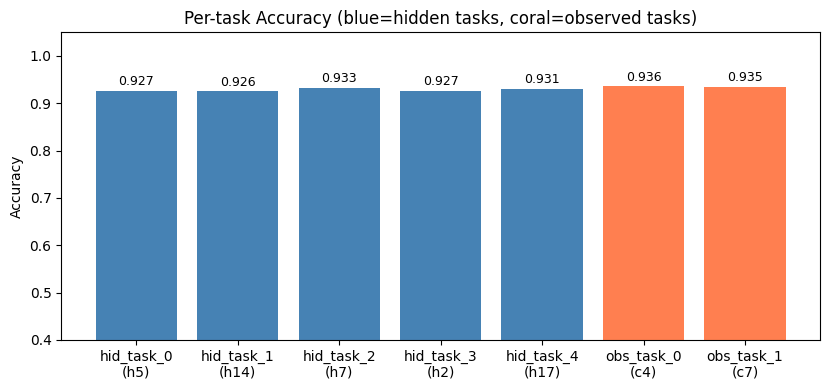

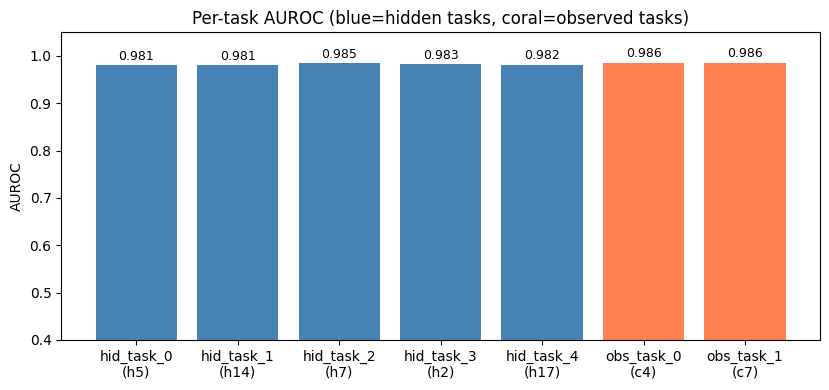

In [2077]:
test_metrics = parse_test_metrics_multilabel(EXPERIMENT_PATH, num_tasks)

# Display summary
summary_df = pd.DataFrame([test_metrics])
display(summary_df[[c for c in summary_df.columns if "task" not in c]])

plot_per_task_metric(test_metrics, metric_name="y_accuracy_task")
plot_per_task_metric(test_metrics, metric_name="y_auroc_task")

In [2078]:
print(test_data["s_hid"])
print(test_data["s_obs"])

print(f"Hidden task weights: {test_data['w_hid']}")
print(f"Observed task weights: {test_data['w_obs']}")

tensor([[-1.2675, -0.1150, -0.6321, -1.2644, -0.2467],
        [ 0.3846, -0.2260,  0.8732, -0.2223, -0.2278],
        [ 0.0625,  0.1126,  2.9607,  1.6316,  0.0601],
        ...,
        [ 2.5448,  1.2906,  1.0132,  3.7869,  0.2660],
        [ 1.0451,  0.0555,  1.6364,  1.3170,  0.5733],
        [-1.2307, -1.2313,  0.9990, -0.7174, -1.2331]])
tensor([[-0.8378, -0.8381],
        [ 1.7747, -0.4126],
        [ 2.1161,  0.4802],
        ...,
        [-0.9077,  3.4098],
        [-0.1447,  0.2178],
        [-0.3853, -0.3856]])
Hidden task weights: tensor([ 0.0000,  0.0000, -0.6096,  0.0000,  0.0000,  0.9749,  0.0000,  0.8919,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000, -0.9521,  0.0000,
         0.0000,  0.5495,  0.0000,  0.0000])
Observed task weights: tensor([0.0000, 0.6214, 0.0000, 0.0000, 0.9304, 0.0000, 0.0000, 0.8412, 0.0000,
        0.0000])


## SCBM performance

In [2079]:
def get_scbm_model_path(full_experiment_path):
    """ 
    Get SCBM model corresponding to specified SCBM res experiment.
    Find model trained on same dataset, i.e. same alpha, beta, sigma_x, standardize.
    """
    full_experiment_path = str(full_experiment_path)
    relative_experiment_path = full_experiment_path.split("multilabel_synthetic/")[-1]


    pattern = re.compile(
        r"alpha_(?P<alpha>[\d.]+)"
        r"_beta_(?P<beta>[\d.]+)"
        r".*?rho_cr_(?P<rho_cr>[\d.]+)"
        r".*?sigma_x_(?P<sigma_x>[\d.]+)"
        r"_standardize_(?P<standardize>True|False)"
    )


    m = pattern.search(relative_experiment_path)
    print(m)
    alpha = float(m["alpha"])          
    beta = float(m["beta"])            
    sigma_x = float(m["sigma_x"])      
    standardize = m["standardize"] == "True"
    rho_cr = float(m["rho_cr"])

    
    
    scbm_root_dir = os.path.join("experiments", "scbm", "multilabel_synthetic")
    
    
    
    for dir in os.listdir(scbm_root_dir):
        m = pattern.search(dir)
        if m is None:
            continue
        dir_alpha = float(m["alpha"])
        dir_beta = float(m["beta"])
        dir_sigma_x = float(m["sigma_x"])
        dir_standardize = m["standardize"]
        dir_rho_cr = float(m["rho_cr"])
        if (dir_alpha == alpha and dir_beta == beta and
            dir_sigma_x == sigma_x and dir_standardize == standardize and dir_rho_cr == rho_cr):
            return os.path.join(scbm_root_dir, dir)
    
    
    
    
    
    
    
    
    
    
    
scbm_full_path = get_scbm_model_path(EXPERIMENT_PATH)
print(f"SCBM model path: {scbm_full_path}")
if not scbm_full_path is None:
        
    scbm_test_metrics = parse_test_metrics_multilabel(scbm_full_path, num_tasks)
    plot_per_task_metric(scbm_test_metrics, metric_name="y_accuracy_task")
    plot_per_task_metric(scbm_test_metrics, metric_name="y_auroc_task")
    summary_df = pd.DataFrame([scbm_test_metrics])
    display(summary_df[[c for c in summary_df.columns if "task" not in c]])
    
else:
    print("No SCBM model found for this experiment.")



 

<re.Match object; span=(8, 101), match='alpha_1.0_beta_0.5_rho_cr_0.0_rho_cc_0.0_rho_rr_0>
SCBM model path: None
No SCBM model found for this experiment.


## Linear head

In [2080]:


def parse_test_metrics_linear_head(experiment_path, num_tasks: int):


    log_path = os.path.join(experiment_path, "log.txt")

    test_line = None
    with open(log_path, "r") as f:
        for line in f:
            if "Final Test Loss" in line:
                test_line = line.strip()

    if test_line is None:
        raise ValueError("No 'Final Test Loss' line found in log.txt")

    def get_metric(name, line=test_line, default=None):
        pattern = rf"{re.escape(name)}:\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)"
        m = re.search(pattern, line)
        return float(m.group(1)) if m else default

    metrics = {
        "y_hamming_accuracy": get_metric("Hamming Acc"),
        "y_macro_auroc": get_metric("Macro AUROC"),
        "y_exact_match": get_metric("Exact Match"),

        # Not present in this log format, but keeping keys for compatibility
        "y_macro_ap": None,
        "c_accuracy": None,
        "c_AUROC": None,
    }

    for k in range(num_tasks):
        metrics[f"y_auroc_task_{k}"] = get_metric(f"y_auroc_{k}")
        metrics[f"y_accuracy_task_{k}"] = get_metric(f"y_accuracy_{k}")

        # Not present in this log format
        metrics[f"y_ap_task_{k}"] = None

    return metrics


def get_linear_head_metrics(EXPERIMENT_PATH):
    data_dir_name = get_data_dir_name_from_log(EXPERIMENT_PATH)
    if data_dir_name is None:
        print("Could not find data_dir in log.txt")
        return

    
    linear_head_root_dir = os.path.join("experiments", "linear_head", "multilabel_synthetic")
    for dir in os.listdir(linear_head_root_dir):
        if dir.startswith(data_dir_name):
            linear_head_full_path = os.path.join(linear_head_root_dir, dir)
            linear_head_test_metrics = parse_test_metrics_linear_head(linear_head_full_path, num_tasks)
            summary_df = pd.DataFrame([linear_head_test_metrics])
            return linear_head_test_metrics
        
        
    
    print(f"data_dir_name: {data_dir_name}")
    



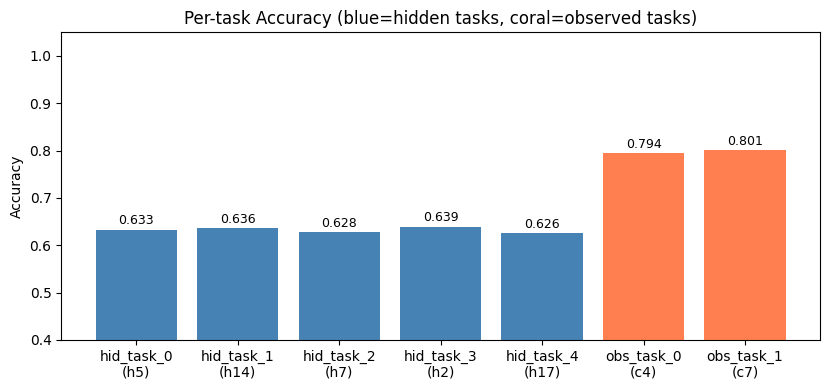

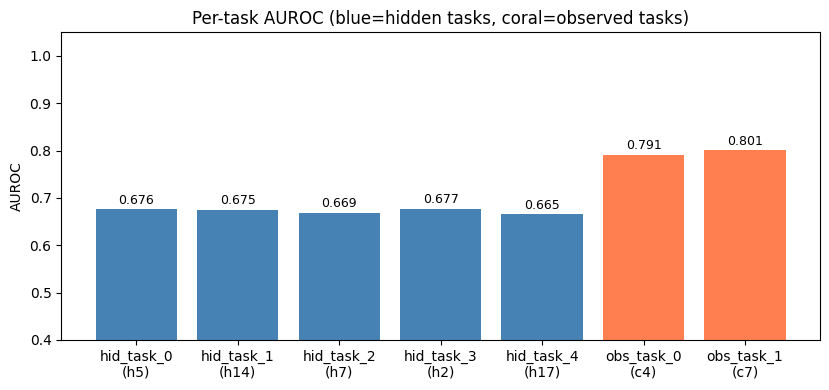

In [2081]:
linear_head_metrics = get_linear_head_metrics(EXPERIMENT_PATH)
linear_head_metrics_df = pd.DataFrame([linear_head_metrics])
plot_per_task_metric(linear_head_metrics, metric_name="y_accuracy_task")
plot_per_task_metric(linear_head_metrics, metric_name="y_auroc_task")

## All model performance together

In [2082]:
scbm_res_metrics = parse_test_metrics_multilabel(EXPERIMENT_PATH, num_tasks)
scbm_full_path = get_scbm_model_path(EXPERIMENT_PATH)
if not scbm_full_path is None:
        
    scbm_metrics = parse_test_metrics_multilabel(scbm_full_path, num_tasks)

else:
    print("No SCBM model found for this experiment.")
    
linear_head_metrics = get_linear_head_metrics(EXPERIMENT_PATH)
linear_head_metrics_df = pd.DataFrame([linear_head_metrics])
linear_head_metrics_df = linear_head_metrics_df[[c for c in linear_head_metrics_df.columns if "task" not in c]]

# Create df for all model performance metrics
all_metrics = {
    "Residual SCBM": scbm_res_metrics,
    "SCBM": scbm_metrics if not scbm_full_path is None else None,
    "Linear Head": linear_head_metrics
}
print(f"SCBM model path: {scbm_full_path}")


all_metrics_df = pd.DataFrame(all_metrics).T
display(all_metrics_df[[c for c in all_metrics_df.columns if "task" not in c]])




<re.Match object; span=(8, 101), match='alpha_1.0_beta_0.5_rho_cr_0.0_rho_cc_0.0_rho_rr_0>
No SCBM model found for this experiment.
SCBM model path: None


,y_macro_auroc,y_macro_ap,y_hamming_accuracy,y_exact_match,c_accuracy,c_AUROC
Residual SCBM,0.984,0.985,0.931,0.644,0.934,0.969
SCBM,None,None,None,None,None,None
Linear Head,0.7079,NaN,0.6796,0.1934,NaN,NaN


## Variance of hidden shared and observed shared

In [2083]:
train_concept_signal = train_data["concept_signal"]
train_residual_signal = train_data["hidden_residual_signal"]

train_hidden_shared = train_residual_signal @ w_hid
train_observed_shared = train_concept_signal @ w_obs

print(f"train_hidden_shared var {train_hidden_shared.var().item():.4f}, train_observed_shared var {train_observed_shared.var().item():.4f}")

for i in train_data["obs_task_idx"]:
    specific_obs = train_concept_signal[:, i] * abs(w_obs[i])
    print(f"variance for observed signal {i}: {specific_obs.var().item():.4f}")



train_hidden_shared var 1.2531, train_observed_shared var 0.7347
variance for observed signal 4: 0.3231
variance for observed signal 7: 0.2652


## Distributed probe — hidden concept recovery

Logistic regression on the full `res_mu` vector to predict each hidden concept. This is the upper bound on recoverable hidden-concept information from the residual channel. Task-bit concepts (hid_task_idx) should show high AUC; non-task-bit concepts should be near chance.

Hidden concept distributed probe (task bits highlighted):


,hidden_concept_idx,distributed_auc,distributed_accuracy,distributed_f1,w_hid,abs_w_hid,is_task_bit,hid_task_k
5,5,0.905191,0.8293,0.821946,0.974940,0.974940,True,0.0
14,14,0.912361,0.8420,0.839137,-0.952066,0.952066,True,1.0
7,7,0.912851,0.8479,0.842040,0.891934,0.891934,True,2.0
2,2,0.903294,0.8365,0.827149,-0.609588,0.609588,True,3.0
17,17,0.907808,0.8350,0.830491,0.549488,0.549488,True,4.0
0,0,0.594203,0.5651,0.562871,0.000000,0.000000,False,NaN
12,12,0.569934,0.5494,0.552443,0.000000,0.000000,False,NaN
18,18,0.588178,0.5641,0.559029,0.000000,0.000000,False,NaN
16,16,0.576219,0.5516,0.547345,0.000000,0.000000,False,NaN
15,15,0.588316,0.5645,0.561121,0.000000,0.000000,False,NaN


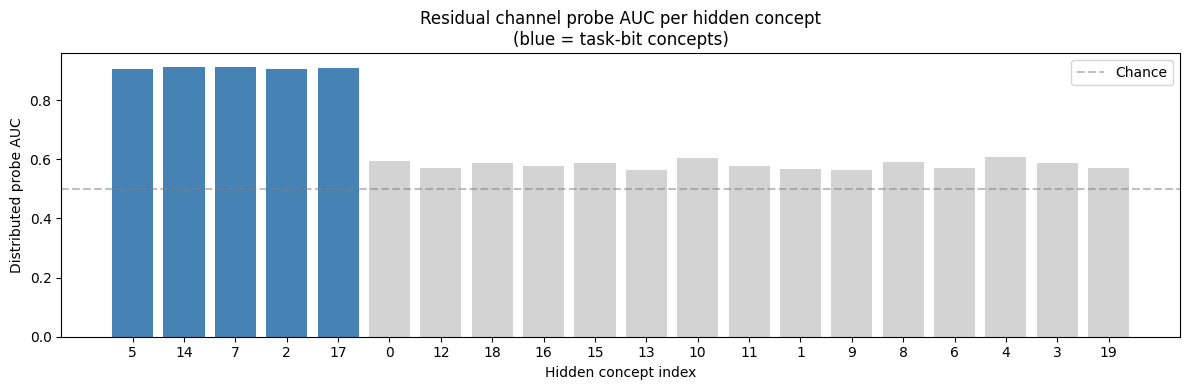

In [2084]:
def probe_baseline(H_pred_train, H_true_train, H_pred_test, H_true_test,
                   column_name="hidden_concept_idx"):
    """Fit one logistic regression per column of H_true, evaluate on test set."""
    H_pred_train = to_numpy(H_pred_train).astype(float)
    H_pred_test = to_numpy(H_pred_test).astype(float)
    H_true_train = to_numpy(H_true_train).astype(float)
    H_true_test = to_numpy(H_true_test).astype(float)

    rows = []
    for h in range(H_true_train.shape[1]):
        clf = make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=1000, class_weight="balanced", random_state=0),
        )
        clf.fit(H_pred_train, H_true_train[:, h])
        probs = clf.predict_proba(H_pred_test)[:, 1]
        preds = (probs >= 0.5).astype(int)
        rows.append({
            column_name: h,
            "distributed_auc": roc_auc_score(H_true_test[:, h], probs),
            "distributed_accuracy": accuracy_score(H_true_test[:, h], preds),
            "distributed_f1": f1_score(H_true_test[:, h], preds),
        })
    return pd.DataFrame(rows)


# Hidden concepts from res_mu
probe_hidden = probe_baseline(
    splits["train"]["res_mu"], splits["train"]["hidden_residuals"],
    splits["test"]["res_mu"], splits["test"]["hidden_residuals"],
)

# Annotate with task weights and task membership
probe_hidden["w_hid"] = probe_hidden["hidden_concept_idx"].apply(lambda i: w_hid[i].item())
probe_hidden["abs_w_hid"] = probe_hidden["w_hid"].abs()
probe_hidden["is_task_bit"]= probe_hidden["hidden_concept_idx"].isin(hid_task_idx.tolist())
probe_hidden["hid_task_k"] = probe_hidden["hidden_concept_idx"].map(task_map_hid)
probe_hidden = probe_hidden.sort_values("abs_w_hid", ascending=False)

print("Hidden concept distributed probe (task bits highlighted):")
display(probe_hidden.head(20))

# Bar chart: probe AUC per hidden concept, coloured by task membership
fig, ax = plt.subplots(figsize=(max(8, hid_dim * 0.6), 4))
colors_bar = ["steelblue" if is_tb else "lightgrey"
              for is_tb in probe_hidden["is_task_bit"]]
ax.bar(probe_hidden["hidden_concept_idx"].astype(str), probe_hidden["distributed_auc"],
       color=colors_bar)
ax.axhline(0.5, color="grey", linestyle="--", alpha=0.5, label="Chance")
ax.set_xlabel("Hidden concept index")
ax.set_ylabel("Distributed probe AUC")
ax.set_title("Residual channel probe AUC per hidden concept\n(blue = task-bit concepts)")
ax.legend()
plt.tight_layout()
plt.show()


## Observed concept probe — ceiling reference

Logistic regression on `c_mu` to predict each observed concept. Provides the AUC ceiling: the residual task-bit probe should approach this.

Observed concept probe (task bits highlighted):


,concept_idx,distributed_auc,distributed_accuracy,distributed_f1,w_obs,abs_w_obs,is_task_bit
4,4,0.969954,0.9308,0.930115,0.930378,0.930378,True
7,7,0.973900,0.9347,0.933967,0.841165,0.841165,True
1,1,0.970827,0.9307,0.929278,0.621388,0.621388,False
0,0,0.969548,0.9298,0.927778,0.000000,0.000000,False
2,2,0.968611,0.9273,0.925687,0.000000,0.000000,False
3,3,0.966626,0.9231,0.921714,0.000000,0.000000,False
5,5,0.965618,0.9231,0.923046,0.000000,0.000000,False
6,6,0.971314,0.9340,0.933427,0.000000,0.000000,False
8,8,0.969609,0.9293,0.929307,0.000000,0.000000,False
9,9,0.969518,0.9262,0.925470,0.000000,0.000000,False


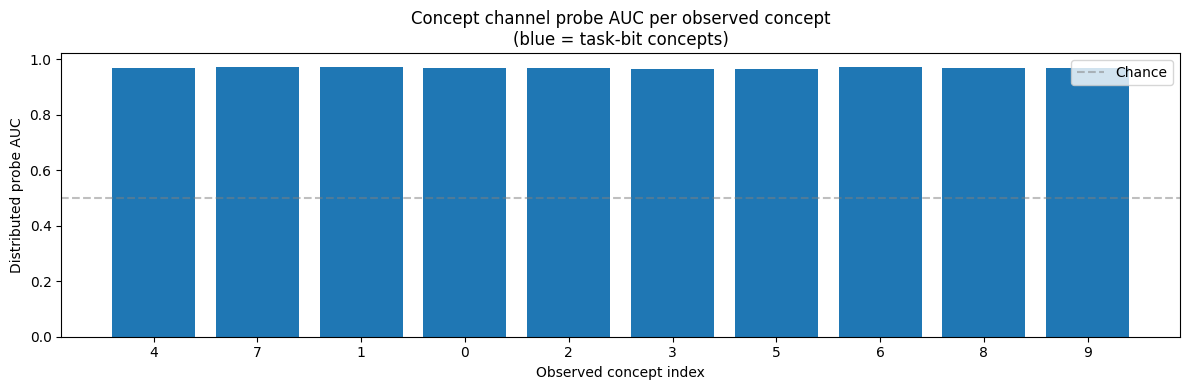

In [2085]:
probe_observed = probe_baseline(
    splits["train"]["c_mu"], splits["train"]["concepts"],
    splits["test"]["c_mu"], splits["test"]["concepts"],
    column_name="concept_idx",
)
probe_observed["w_obs"] = probe_observed["concept_idx"].apply(lambda i: w_obs[i].item())
probe_observed["abs_w_obs"] = probe_observed["w_obs"].abs()
probe_observed["is_task_bit"]= probe_observed["concept_idx"].isin(obs_task_idx.tolist())
probe_observed = probe_observed.sort_values("abs_w_obs", ascending=False)

print("Observed concept probe (task bits highlighted):")
display(probe_observed)

# Bar chart: probe AUC per hidden concept, coloured by task membership
fig, ax = plt.subplots(figsize=(max(8, hid_dim * 0.6), 4))

ax.bar(probe_observed["concept_idx"].astype(str), probe_observed["distributed_auc"])
ax.axhline(0.5, color="grey", linestyle="--", alpha=0.5, label="Chance")
ax.set_xlabel("Observed concept index")
ax.set_ylabel("Distributed probe AUC")
ax.set_title("Concept channel probe AUC per observed concept\n(blue = task-bit concepts)")
ax.legend()
plt.tight_layout()
plt.show()


## MLP from raw x → hidden concepts / observed concepts

Upper bound: how much hidden-concept information is in x with a nonlinear model. If MLP AUC >> probe AUC for task-bit concepts, the residual channel is leaving signal on the table.

In [2086]:
class ConceptMLP(nn.Module):
    def __init__(self, input_dim, num_outputs, hidden_dims=(128, 64), dropout=0.1):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, num_outputs))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)


def evaluate_mlp(model, loader, device):
    model.eval()
    all_logits, all_targets = [], []
    with torch.no_grad():
        for xb, yb in loader:
            all_logits.append(model(xb.to(device)).cpu())
            all_targets.append(yb)
    logits = torch.cat(all_logits)
    targets = torch.cat(all_targets)
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()

    per_col = []
    for j in range(targets.shape[1]):
        y_true = to_numpy(targets[:, j])
        y_prob = to_numpy(probs[:, j])
        y_pred = to_numpy(preds[:, j])
        row = {"col_idx": j,
               "accuracy": accuracy_score(y_true, y_pred),
               "f1": f1_score(y_true, y_pred, zero_division=0)}
        if len(np.unique(y_true)) > 1:
            row["auc"] = roc_auc_score(y_true, y_prob)
        else:
            row["auc"] = np.nan
        per_col.append(row)
    per_col_df = pd.DataFrame(per_col)

    return {
        "macro_auc": float(np.nanmean(per_col_df["auc"])),
        "hamming_acc": (preds == targets).float().mean().item(),
        "exact_match": (preds == targets).all(dim=1).float().mean().item(),
        "macro_f1": float(np.nanmean(per_col_df["f1"])),
    }, per_col_df


def train_mlp_from_x(train_data, val_data, test_data, target_key,
                     hidden_dims=(128, 64), dropout=0.1, lr=1e-3,
                     weight_decay=1e-4, batch_size=512, epochs=100, patience=10):
    device = torch.device("cpu")
    x_mean = train_data["x"].float().mean(0, keepdim=True)
    x_std = train_data["x"].float().std(0, keepdim=True).clamp_min(1e-6)

    def normalize_x(data):
        data = data.copy()
        data["x"] = (data["x"].float() - x_mean) / x_std
        return data

    tr = normalize_x(train_data)
    va = normalize_x(val_data)
    te = normalize_x(test_data)
    


    def loader(split, shuffle=False):
        ds = torch.utils.data.TensorDataset(split["x"], split[target_key].float())
        return torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

    model = ConceptMLP(tr["x"].shape[1], tr[target_key].shape[1],
                       hidden_dims=hidden_dims, dropout=dropout).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val, best_state, epochs_no_improve = -float("inf"), None, 0
    for epoch in range(1, epochs + 1):
        model.train()
        for xb, yb in loader(tr, shuffle=True):
            opt.zero_grad()
            F.binary_cross_entropy_with_logits(model(xb.to(device)), yb.to(device)).backward()
            opt.step()
        val_metrics, _ = evaluate_mlp(model, loader(va), device)
        if val_metrics["macro_auc"] > best_val:
            best_val = val_metrics["macro_auc"]
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break

    model.load_state_dict(best_state)
    test_metrics, per_col_df = evaluate_mlp(model, loader(te), device)
    return test_metrics, per_col_df





In [2087]:
print("Training MLP(x → hidden concepts) — upper bound on recoverable information...")
mlp_hid_metrics, mlp_hid_per_col = train_mlp_from_x(
    train_data, val_data, test_data, target_key="hidden_residuals"
)
mlp_hid_per_col["is_task_bit"] = mlp_hid_per_col["col_idx"].isin(hid_task_idx.tolist())
mlp_hid_per_col["hid_task_k"] = mlp_hid_per_col["col_idx"].map(task_map_hid)
print("MLP(x → hidden) aggregate:", mlp_hid_metrics)
display(mlp_hid_per_col)


Training MLP(x → hidden concepts) — upper bound on recoverable information...
MLP(x → hidden) aggregate: {'macro_auc': 0.9671012347774713, 'hamming_acc': 0.9319199919700623, 'exact_match': 0.25130000710487366, 'macro_f1': 0.9285236668055139}


,col_idx,accuracy,f1,auc,is_task_bit,hid_task_k
0,0,0.9323,0.928231,0.965955,False,NaN
1,1,0.9280,0.924449,0.963860,False,NaN
2,2,0.9251,0.919730,0.962010,True,3.0
3,3,0.9405,0.937611,0.970530,False,NaN
4,4,0.9222,0.916720,0.961417,False,NaN
5,5,0.9264,0.922379,0.966462,True,0.0
6,6,0.9323,0.928729,0.968640,False,NaN
7,7,0.9390,0.936152,0.971948,True,2.0
8,8,0.9325,0.929238,0.969151,False,NaN
9,9,0.9244,0.922778,0.963419,False,NaN


In [2088]:
print("Training MLP(x → observed concepts) — upper bound on recoverable information...")
mlp_obs_metrics, mlp_obs_per_col = train_mlp_from_x(
    train_data, val_data, test_data, target_key="concepts"
)
mlp_obs_per_col["is_task_bit"] = mlp_obs_per_col["col_idx"].isin(obs_task_idx.tolist())
mlp_obs_per_col["obs_task_k"] = mlp_obs_per_col["col_idx"].map(task_map_obs)
print("MLP(x → observed) aggregate:", mlp_obs_metrics)

display(mlp_obs_per_col)


Training MLP(x → observed concepts) — upper bound on recoverable information...
MLP(x → observed) aggregate: {'macro_auc': 0.9709029547925878, 'hamming_acc': 0.9387199878692627, 'exact_match': 0.5396000146865845, 'macro_f1': 0.9358856045917179}


,col_idx,accuracy,f1,auc,is_task_bit,obs_task_k
0,0,0.9396,0.936112,0.972359,False,NaN
1,1,0.9368,0.933093,0.968234,False,NaN
2,2,0.9371,0.933852,0.969985,False,NaN
3,3,0.9375,0.933925,0.969368,False,NaN
4,4,0.9388,0.935863,0.970616,True,0.0
5,5,0.9335,0.931095,0.968150,False,NaN
6,6,0.9467,0.944589,0.974113,False,NaN
7,7,0.9409,0.938315,0.974059,True,1.0
8,8,0.9372,0.935271,0.971072,False,NaN
9,9,0.9391,0.936740,0.971075,False,NaN


## Raw axis AUC matrix — hidden concepts vs residual dimensions

Each cell = AUC of residual dimension r_j for predicting hidden concept h_i. Task-bit rows (hid_task_idx) should show elevated AUC; other rows should be ~0.5.

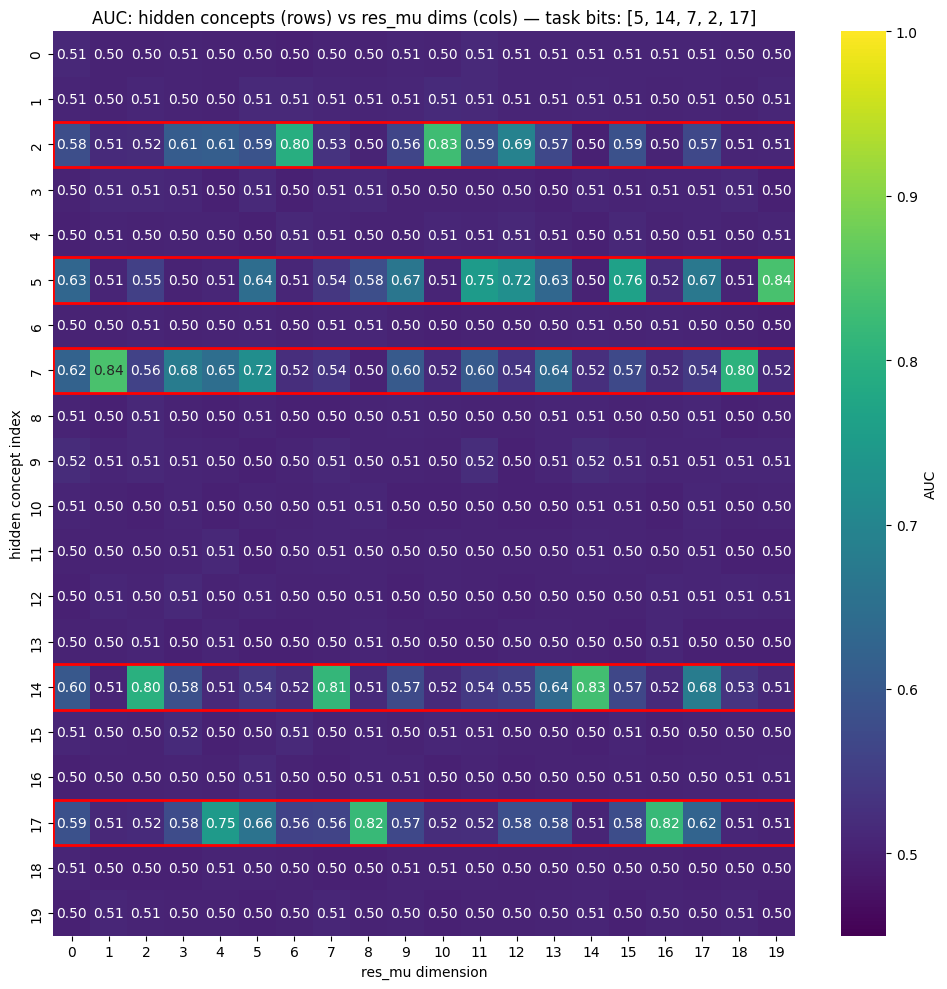

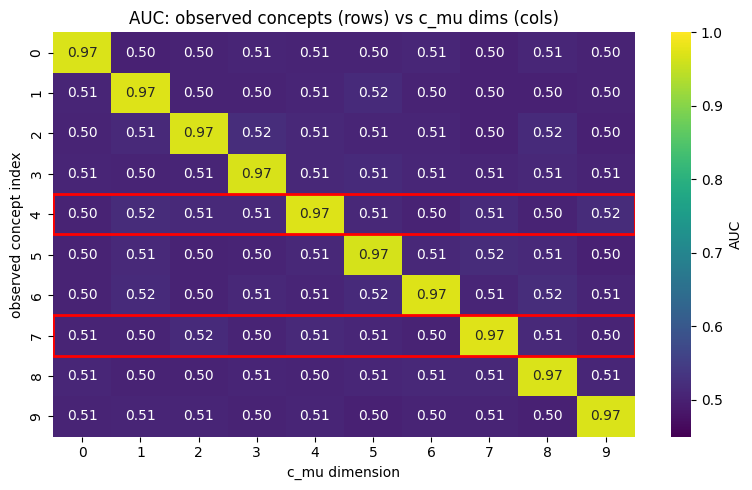

In [2089]:
def auc_matrix(true_labels, pred_scores):
    """Compute AUC for every (row, col) pair. Shape: (n_true, n_pred)."""
    n_true = true_labels.shape[1]
    n_pred = pred_scores.shape[1]
    mat = np.zeros((n_true, n_pred))
    for i in range(n_true):
        for j in range(n_pred):
            if len(np.unique(true_labels[:, i])) > 1:
                mat[i, j] = calculate_auc(true_labels[:, i], pred_scores[:, j])
            else:
                mat[i, j] = np.nan
    return mat


def plot_heatmap(mat, title, x_label, y_label, annot=True,
                 highlight_rows=None, highlight_cols=None):
    fig, ax = plt.subplots(figsize=(max(8, mat.shape[1] * 0.5),
                                    max(5, mat.shape[0] * 0.5)))
    sns.heatmap(mat, annot=annot, fmt=".2f", cmap="viridis",
                vmin=0.45, vmax=1.0, ax=ax, cbar_kws={"label": "AUC"})
    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    if highlight_rows is not None:
        for r in highlight_rows:
            ax.add_patch(plt.Rectangle((0, r), mat.shape[1], 1,
                         fill=False, edgecolor="red", lw=2))
    plt.tight_layout()
    plt.show()


# Hidden concepts vs residual dimensions
auc_mat_hid_res = auc_matrix(
    to_numpy(test_data["hidden_residuals"]),
    to_numpy(test_data["res_mu"]),
)
plot_heatmap(
    auc_mat_hid_res,
    title=f"AUC: hidden concepts (rows) vs res_mu dims (cols) — task bits: {hid_task_idx.tolist()}",
    x_label="res_mu dimension",
    y_label="hidden concept index",
    highlight_rows=hid_task_idx.tolist(),
    annot=True,
)

# Observed concepts vs c_mu (ceiling reference)
auc_mat_obs_cmu = auc_matrix(
    to_numpy(test_data["concepts"]),
    to_numpy(test_data["c_mu"]),
)
plot_heatmap(
    auc_mat_obs_cmu,
    title="AUC: observed concepts (rows) vs c_mu dims (cols)",
    x_label="c_mu dimension",
    y_label="observed concept index",
    highlight_rows=obs_task_idx.tolist(),
    annot=True,
)


## Reusable SVD / PCA / ICA helpers

Pass any train/test matrix into these helpers to inspect rank, PCA directions, or ICA directions. Optional labels add AUC heatmaps and alignment summaries.

In [2090]:
def nan_best(mat, axis):
    """Return nan-safe argmax indices and max values along an axis."""
    values = np.asarray(mat, dtype=float)
    valid = ~np.all(np.isnan(values), axis=axis)
    idx = np.full(values.shape[1 - axis], -1, dtype=int)
    best = np.full(values.shape[1 - axis], np.nan)
    if axis == 0:
        idx[valid] = np.nanargmax(values[:, valid], axis=0)
        best[valid] = np.nanmax(values[:, valid], axis=0)
    else:
        idx[valid] = np.nanargmax(values[valid, :], axis=1)
        best[valid] = np.nanmax(values[valid, :], axis=1)
    return idx, best


def as_2d_numpy(x, name="X"):
    """Convert tensors/dataframes/arrays to a 2D float numpy array."""
    arr = to_numpy(x).astype(float)
    if arr.ndim != 2:
        raise ValueError(f"{name} must be 2D, got shape {arr.shape}")
    return arr


def component_auc_summary(auc_mat, component_prefix="component",
                          hidden_idx=None, task_map=None):
    best_label, best_auc = nan_best(auc_mat, axis=0)
    component_summary = pd.DataFrame({
        component_prefix: np.arange(auc_mat.shape[1]),
        "best_label_idx": best_label,
        "best_auc": best_auc,
    })
    if hidden_idx is not None:
        hidden_idx = list(hidden_idx)
        component_summary["best_is_task_bit"] = component_summary["best_label_idx"].isin(hidden_idx)
    if task_map is not None:
        component_summary["best_task_k"] = component_summary["best_label_idx"].map(task_map)

    best_component, best_component_auc = nan_best(auc_mat, axis=1)
    label_summary = pd.DataFrame({
        "label_idx": np.arange(auc_mat.shape[0]),
        f"best_{component_prefix}": best_component,
        f"best_{component_prefix}_auc": best_component_auc,
    })
    if hidden_idx is not None:
        label_summary["is_task_bit"] = label_summary["label_idx"].isin(hidden_idx)
    if task_map is not None:
        label_summary["task_k"] = label_summary["label_idx"].map(task_map)
    label_summary = label_summary.sort_values(f"best_{component_prefix}_auc", ascending=False)
    return component_summary, label_summary


def run_svd_analysis(X, name="input", expected_rank=None, top_n=15,
                     plot=True, display_tables=True):
    """Center X, run SVD, plot feature correlations and cumulative variance."""
    X = as_2d_numpy(X, name=name)
    X_centered = X - X.mean(axis=0)

    corr = np.corrcoef(X_centered.T)
    if plot:
        fig, ax = plt.subplots(figsize=(8, 6))
        sns.heatmap(corr, center=0, ax=ax, cmap="RdBu_r")
        ax.set_title(f"Correlation between {name} dimensions")
        plt.tight_layout()
        plt.show()

    u, s, vh = np.linalg.svd(X_centered, full_matrices=False)
    total = np.sum(s**2)
    explained = np.zeros_like(s) if total == 0 else s**2 / total
    cumvar = np.cumsum(explained)

    axis_variance = pd.DataFrame({
        "axis": np.arange(1, len(explained) + 1),
        "singular_value": s,
        "explained_variance": explained,
        "explained_variance_%": 100 * explained,
        "cumulative_variance_%": 100 * cumvar,
    })
    if display_tables:
        print(f"Variance explained by each {name} SVD axis:")
        display(axis_variance.round(4))

    if plot:
        n_plot = min(top_n, len(s))
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].bar(np.arange(1, n_plot + 1), s[:n_plot])
        axes[0].set_xlabel("Singular value rank")
        axes[0].set_ylabel("Singular value")
        axes[0].set_title(f"Top singular values of {name}")

        axes[1].plot(np.arange(1, len(cumvar) + 1), cumvar, marker="o")
        axes[1].axhline(0.95, color="red", linestyle="--", alpha=0.5, label="95%")
        axes[1].axhline(0.99, color="orange", linestyle="--", alpha=0.5, label="99%")
        if expected_rank is not None:
            axes[1].axvline(expected_rank, color="steelblue", linestyle="--",
                            label=f"expected rank={expected_rank}")
        axes[1].set_xlabel("Number of components")
        axes[1].set_ylabel("Cumulative explained variance")
        axes[1].set_title(f"Effective rank of {name}")
        axes[1].legend()
        plt.tight_layout()
        plt.show()

    if expected_rank is not None and len(cumvar):
        k = min(expected_rank, len(cumvar))
        print(f"Expected effective rank: {expected_rank}")
        print(f"Variance explained by top-{k} components: {cumvar[k - 1]:.4f}")
    if len(cumvar):
        print(f"Variance explained by top-1: {cumvar[0]:.4f}")
        n_print = min((expected_rank or 3) + 2, len(s))
        print(f"Top singular values: {s[:n_print].round(1)}")

    return {
        "u": u,
        "s": s,
        "vh": vh,
        "centered": X_centered,
        "corr": corr,
        "axis_variance": axis_variance,
        "explained": explained,
        "cumvar": cumvar,
    }


def run_pca_analysis(train_X, test_X=None, true_labels=None, n_components=None,
                     name="input", label_name="labels", highlight_rows=None,
                     task_map=None, random_state=0, plot=True, display_tables=True):
    """Fit PCA on train_X, transform test_X, and optionally score components against labels."""
    train_X = as_2d_numpy(train_X, name=f"train {name}")
    test_X = train_X if test_X is None else as_2d_numpy(test_X, name=f"test {name}")
    if n_components is None:
        n_components = min(train_X.shape[1], train_X.shape[0])
    n_components = min(n_components, train_X.shape[1], train_X.shape[0])

    model = make_pipeline(
        StandardScaler(),
        PCA(n_components=n_components, random_state=random_state),
    )
    train_scores = model.fit_transform(train_X)
    test_scores = model.transform(test_X)
    pca_step = model.named_steps["pca"]

    component_variance = pd.DataFrame({
        "pca_component": np.arange(n_components),
        "explained_variance_ratio": pca_step.explained_variance_ratio_,
        "explained_variance_ratio_%": 100 * pca_step.explained_variance_ratio_,
        "cumulative_variance_%": 100 * np.cumsum(pca_step.explained_variance_ratio_),
    })
    if display_tables:
        print(f"PCA variance for {name}:")
        display(component_variance.round(4))

    auc_mat = None
    component_summary = None
    label_summary = None
    if true_labels is not None:
        true_labels = as_2d_numpy(true_labels, name=label_name)
        auc_mat = auc_matrix(true_labels, test_scores)
        if plot:
            plot_heatmap(
                auc_mat,
                title=f"AUC: {label_name} (rows) vs PCA({name}) components (cols)",
                x_label="PCA component",
                y_label=label_name,
                highlight_rows=None if highlight_rows is None else list(highlight_rows),
                annot=True,
            )
        component_summary, label_summary = component_auc_summary(
            auc_mat,
            component_prefix="pca_component",
            hidden_idx=highlight_rows,
            task_map=task_map,
        )
        if display_tables:
            print("Best label alignment for each PCA component:")
            display(component_summary.round(4))
            print("Labels ranked by best PCA-component AUC:")
            display(label_summary.round(4))

    return {
        "model": model,
        "train_scores": train_scores,
        "test_scores": test_scores,
        "component_variance": component_variance,
        "auc_mat": auc_mat,
        "component_summary": component_summary,
        "label_summary": label_summary,
    }


def run_ica_analysis(train_X, test_X=None, true_train_labels=None, true_test_labels=None,
                     n_components=None, expected_rank=None, name="input",
                     label_name="labels", highlight_rows=None, task_map=None,
                     random_state=0, max_iter=5000, tol=1e-4,
                     assignment_threshold=0.7, plot=True, display_tables=True):
    """Fit ICA on train_X, transform test_X, and optionally evaluate train-fixed component assignments."""
    from scipy.optimize import linear_sum_assignment

    train_X = as_2d_numpy(train_X, name=f"train {name}")
    test_X = train_X if test_X is None else as_2d_numpy(test_X, name=f"test {name}")
    if n_components is None:
        n_components = expected_rank or min(train_X.shape[1], train_X.shape[0])
    n_components = min(n_components, train_X.shape[1], train_X.shape[0])

    model = make_pipeline(
        StandardScaler(),
        FastICA(
            n_components=n_components,
            whiten="unit-variance",
            max_iter=max_iter,
            tol=tol,
            random_state=random_state,
        ),
    )
    train_scores = model.fit_transform(train_X)
    test_scores = model.transform(test_X)

    results = {
        "model": model,
        "train_scores": train_scores,
        "test_scores": test_scores,
        "train_auc_mat": None,
        "test_auc_mat": None,
        "component_summary": None,
        "label_summary": None,
        "assignment": None,
        "component_corr": None,
        "mean_abs_offdiag_corr": None,
    }

    if true_train_labels is not None:
        true_train_labels = as_2d_numpy(true_train_labels, name=f"train {label_name}")
        results["train_auc_mat"] = auc_matrix(true_train_labels, train_scores)
        if plot:
            plot_heatmap(
                results["train_auc_mat"],
                title=f"AUC (TRAIN): {label_name} (rows) vs ICA({name}) components (cols)",
                x_label="ICA component",
                y_label=label_name,
                highlight_rows=None if highlight_rows is None else list(highlight_rows),
                annot=True,
            )

    if true_test_labels is not None:
        true_test_labels = as_2d_numpy(true_test_labels, name=f"test {label_name}")
        results["test_auc_mat"] = auc_matrix(true_test_labels, test_scores)
        if plot:
            plot_heatmap(
                results["test_auc_mat"],
                title=f"AUC (TEST): {label_name} (rows) vs ICA({name}) components (cols)",
                x_label="ICA component",
                y_label=label_name,
                highlight_rows=None if highlight_rows is None else list(highlight_rows),
                annot=True,
            )
        component_summary, label_summary = component_auc_summary(
            results["test_auc_mat"],
            component_prefix="ica_component",
            hidden_idx=highlight_rows,
            task_map=task_map,
        )
        results["component_summary"] = component_summary
        results["label_summary"] = label_summary
        if display_tables:
            print("[diagnostic, test-set argmax] Best label alignment for each ICA component:")
            display(component_summary.round(4))
            print("[diagnostic, test-set argmax] Labels ranked by best ICA-component AUC:")
            display(label_summary.round(4))

    if results["train_auc_mat"] is not None and results["test_auc_mat"] is not None:
        row_ind, col_ind = linear_sum_assignment(
            1 - np.nan_to_num(results["train_auc_mat"], nan=0.0)
        )
        assignment = pd.DataFrame({
            "label_idx": row_ind,
            "matched_component": col_ind,
            "train_auc": results["train_auc_mat"][row_ind, col_ind],
        })
        assignment["test_auc"] = [
            results["test_auc_mat"][label_idx, comp_idx]
            for label_idx, comp_idx in zip(assignment["label_idx"], assignment["matched_component"])
        ]
        if highlight_rows is not None:
            assignment["is_task_bit"] = assignment["label_idx"].isin(list(highlight_rows))
        if task_map is not None:
            assignment["task_k"] = assignment["label_idx"].map(task_map)
        assignment["discovered"] = assignment["test_auc"] > assignment_threshold
        assignment = assignment.sort_values("test_auc", ascending=False)
        results["assignment"] = assignment
        if display_tables:
            print("[reported] One-to-one assignment fit on train, scored on test:")
            display(assignment.round(4))
            if "is_task_bit" in assignment:
                print("Mean test AUC by task-bit status:")
                print(assignment.groupby("is_task_bit")["test_auc"].mean().round(4))
                n_task = assignment["is_task_bit"].sum()
                n_discovered = assignment.loc[assignment["is_task_bit"], "discovered"].sum()
                print(f"Task-bit labels discovered (test AUC > {assignment_threshold}): {n_discovered} / {n_task}")

    component_corr = np.corrcoef(test_scores.T)
    results["component_corr"] = component_corr
    offdiag = component_corr[np.triu_indices_from(component_corr, k=1)]
    results["mean_abs_offdiag_corr"] = np.mean(np.abs(offdiag)) if len(offdiag) else 0.0
    if plot:
        fig, ax = plt.subplots(figsize=(max(5, 0.7 * n_components), max(4, 0.6 * n_components)))
        sns.heatmap(component_corr, center=0, vmin=-1, vmax=1,
                    cmap="RdBu_r", annot=True, fmt=".2f", ax=ax)
        ax.set_title(f"Correlation between ICA({name}) components on test data")
        ax.set_xlabel("ICA component")
        ax.set_ylabel("ICA component")
        plt.tight_layout()
        plt.show()
    print(f"ICA components fitted: {n_components}")
    print(f"Mean absolute off-diagonal ICA component correlation: {results['mean_abs_offdiag_corr']:.4f}")

    return results


## Residual mu decompositions

Change `train_X`, `test_X`, or the label arrays to reuse the same diagnostics on another representation.

In [2091]:
train_X = train_data["res_mu"]
test_X = test_data["res_mu"]
train_labels = train_data["hidden_residuals"]
test_labels = test_data["hidden_residuals"]
print(f"train_X shape: {train_X.shape}, test_X shape: {test_X.shape}")
print(f"train_labels shape: {train_labels.shape}, test_labels shape: {test_labels.shape}")

train_X shape: torch.Size([30000, 20]), test_X shape: torch.Size([10000, 20])
train_labels shape: torch.Size([30000, 20]), test_labels shape: torch.Size([10000, 20])


### SVD

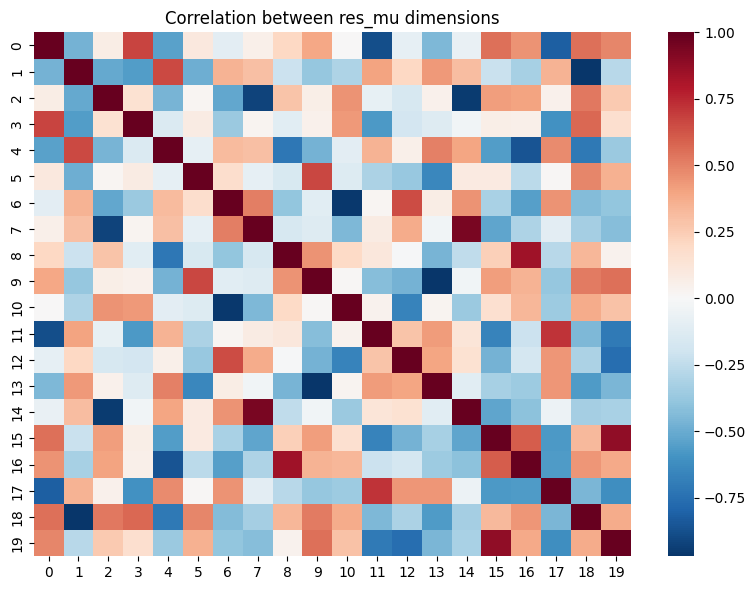

Variance explained by each res_mu SVD axis:


,axis,singular_value,explained_variance,explained_variance_%,cumulative_variance_%
0,1,2396.4608,0.3994,39.9363,39.9363
1,2,1639.8320,0.1870,18.6993,58.6356
2,3,1225.3526,0.1044,10.4412,69.0768
3,4,1180.8624,0.0970,9.6967,78.7735
4,5,1165.6551,0.0945,9.4486,88.2221
5,6,1115.4728,0.0865,8.6526,96.8747
6,7,554.9423,0.0214,2.1415,99.0162
7,8,171.4751,0.0020,0.2045,99.2207
8,9,149.9558,0.0016,0.1564,99.3770
9,10,126.4560,0.0011,0.1112,99.4882


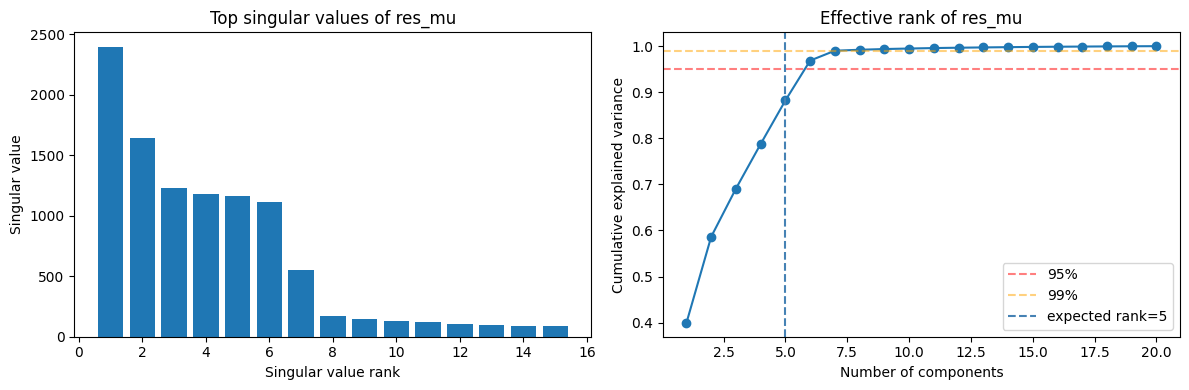

Expected effective rank: 5
Variance explained by top-5 components: 0.8822
Variance explained by top-1: 0.3994
Top singular values: [2396.5 1639.8 1225.4 1180.9 1165.7 1115.5  554.9]


In [2092]:
svd_res_mu = run_svd_analysis(
    test_X,
    name="res_mu",
    expected_rank=num_hid_tasks,
)

### PCA

PCA variance for res_mu:


,pca_component,explained_variance_ratio,explained_variance_ratio_%,cumulative_variance_%
0,0,0.3893,38.9338,38.9338
1,1,0.1764,17.6385,56.5723
2,2,0.1149,11.4939,68.0662
3,3,0.1067,10.6731,78.7393
4,4,0.0918,9.1820,87.9213
5,5,0.0888,8.8806,96.8019


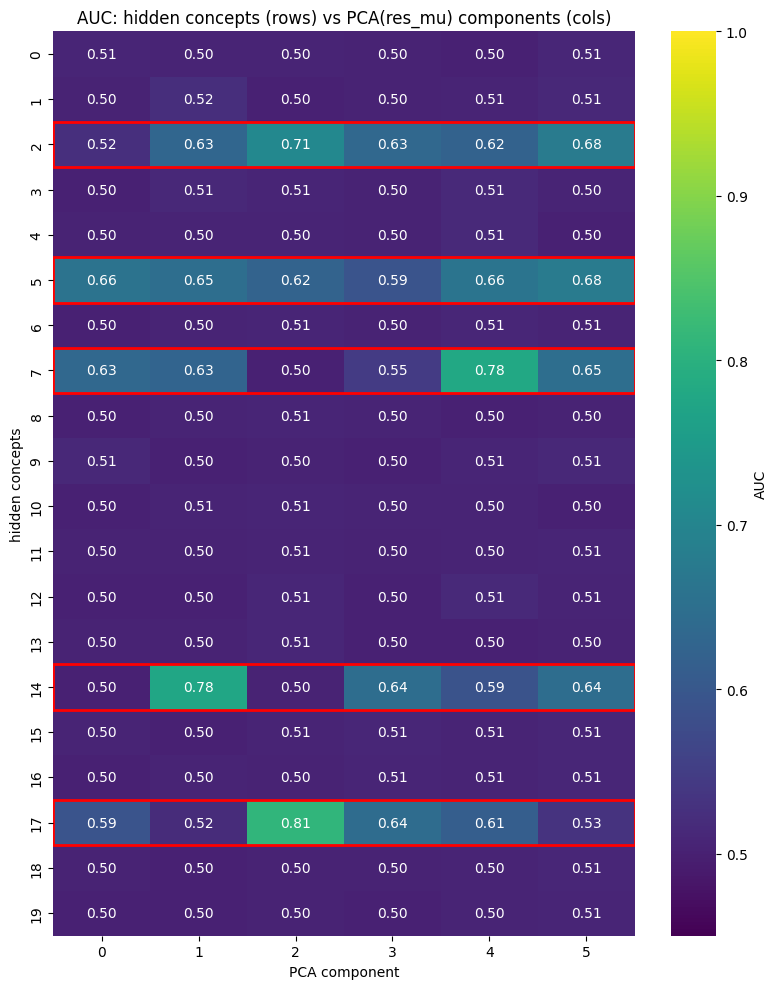

Best label alignment for each PCA component:


,pca_component,best_label_idx,best_auc,best_is_task_bit,best_task_k
0,0,5,0.6586,True,0
1,1,14,0.7752,True,1
2,2,17,0.8104,True,4
3,3,14,0.6435,True,1
4,4,7,0.7798,True,2
5,5,5,0.6769,True,0


Labels ranked by best PCA-component AUC:


,label_idx,best_pca_component,best_pca_component_auc,is_task_bit,task_k
17,17,2,0.8104,True,4.0
7,7,4,0.7798,True,2.0
14,14,1,0.7752,True,1.0
2,2,2,0.7070,True,3.0
5,5,5,0.6769,True,0.0
1,1,1,0.5211,False,NaN
12,12,4,0.5144,False,NaN
4,4,4,0.5126,False,NaN
3,3,4,0.5126,False,NaN
9,9,5,0.5121,False,NaN


In [2093]:
pca_res_mu = run_pca_analysis(
    train_X,
    test_X,
    true_labels=test_labels,
    n_components=min(num_hid_tasks + 1, train_X.shape[1]),
    name="res_mu",
    label_name="hidden concepts",
    highlight_rows=hid_task_idx.tolist(),
    task_map=task_map_hid,
)

### ICA

/Users/stephenmarcou/Documents/ETH Zurich/Cambridge/Code/SCBM_implementation/scbm_implementation/lib/python3.11/site-packages/sklearn/decomposition/_fastica.py:132: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


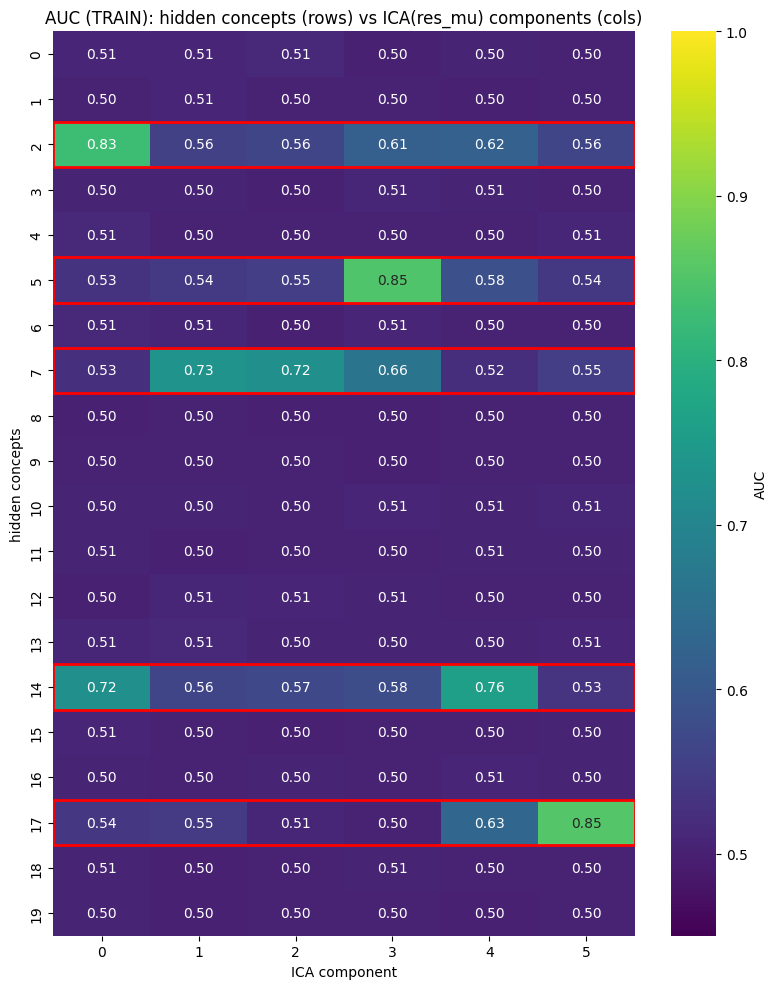

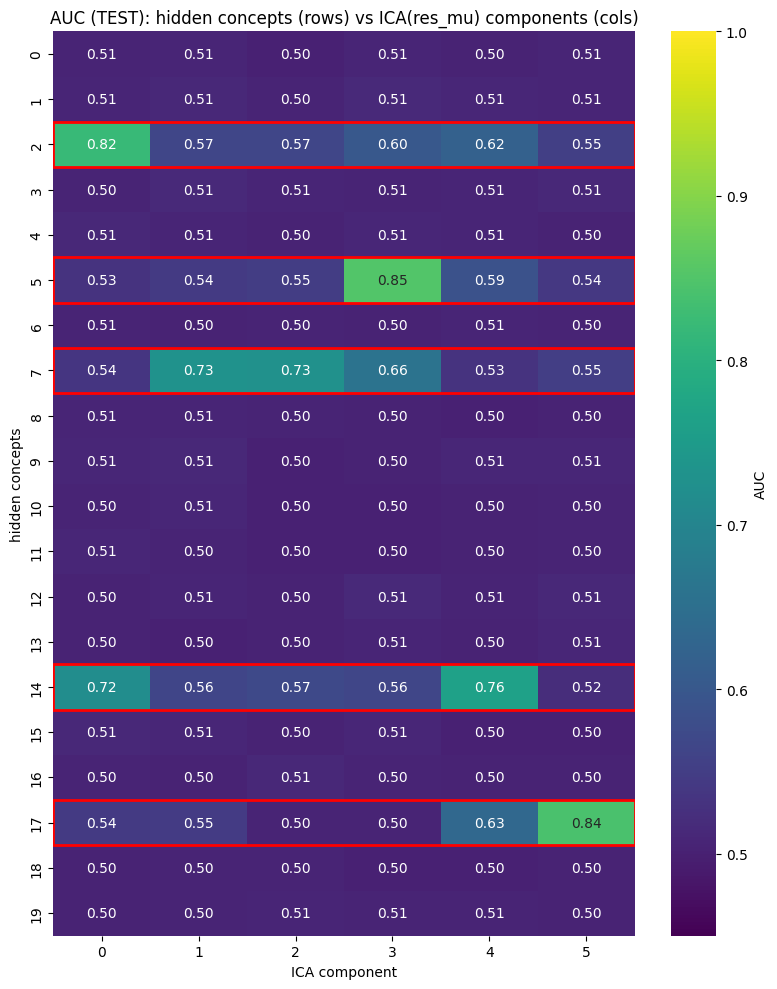

[diagnostic, test-set argmax] Best label alignment for each ICA component:


,ica_component,best_label_idx,best_auc,best_is_task_bit,best_task_k
0,0,2,0.8214,True,3
1,1,7,0.7281,True,2
2,2,7,0.7256,True,2
3,3,5,0.8499,True,0
4,4,14,0.7634,True,1
5,5,17,0.8426,True,4


[diagnostic, test-set argmax] Labels ranked by best ICA-component AUC:


,label_idx,best_ica_component,best_ica_component_auc,is_task_bit,task_k
5,5,3,0.8499,True,0.0
17,17,5,0.8426,True,4.0
2,2,0,0.8214,True,3.0
14,14,4,0.7634,True,1.0
7,7,1,0.7281,True,2.0
12,12,3,0.5141,False,NaN
1,1,3,0.5138,False,NaN
3,3,1,0.5126,False,NaN
15,15,0,0.5118,False,NaN
9,9,1,0.5115,False,NaN


[reported] One-to-one assignment fit on train, scored on test:


,label_idx,matched_component,train_auc,test_auc,is_task_bit,task_k,discovered
2,5,3,0.8481,0.8499,True,0.0,True
5,17,5,0.8532,0.8426,True,4.0,True
1,2,0,0.8274,0.8214,True,3.0,True
4,14,4,0.7573,0.7634,True,1.0,True
3,7,1,0.7315,0.7281,True,2.0,True
0,0,2,0.5117,0.5000,False,NaN,False


Mean test AUC by task-bit status:
is_task_bit
False    0.5000
True     0.8011
Name: test_auc, dtype: float64
Task-bit labels discovered (test AUC > 0.7): 5 / 5


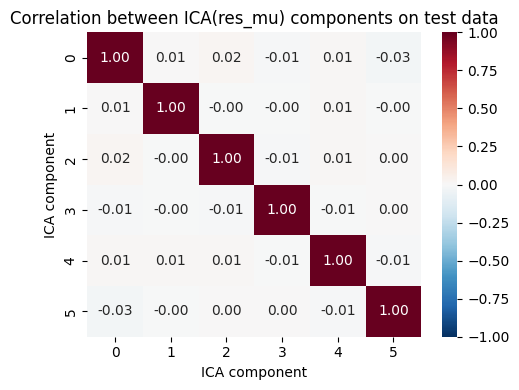

ICA components fitted: 6
Mean absolute off-diagonal ICA component correlation: 0.0083


In [2094]:
ica_res_mu = run_ica_analysis(
    train_X,
    test_X,
    true_train_labels=train_labels,
    true_test_labels=test_labels,
    n_components=min(num_hid_tasks + 1, train_X.shape[1]),
    name="res_mu",
    label_name="hidden concepts",
    highlight_rows=hid_task_idx.tolist(),
    task_map=task_map_hid,
    assignment_threshold=0.7,
)

## Task-head readout + ΔAUC gate (primary discovery method)

Non-oracle pipeline, usable on real data (only needs model activations + task labels `y`):

1. **Layer 1 — `c_mu` residualization**: regress `res_mu` on `c_mu` (OLS) and keep the residual.
   Unlike the oracle `a_c` cleaning above, this also removes *observed-concept leakage* from the
   residual channel. Empirically this is what breaks raw ICA at `sigma_x=0.5`: concept 14 fails at
   **all** beta values incl. beta=0, oracle `a_c` removal does not fix it, `c_mu` removal does (5/5).
2. **ΔAUC gate**: AUC of `y_k` from `[c_mu, res_mu]` minus AUC from `c_mu` alone. Large positive
   delta ⇒ task k is residual-driven. (Caveat: at beta>0 observed tasks also gain, because `y_obs`
   contains the hidden background `a_r` — the gate detects *residual-dependent*, not *hidden* per se.)
3. **Task-head readout**: one linear probe per task label on the cleaned residual; its decision
   axis is a candidate hidden-concept direction *already labeled with its task* — no ICA
   identifiability assumptions, no Hungarian matching. Ground-truth hidden concepts are used
   only for validation.

Reference numbers (beta=1, sigma_x=0.5): probe ceiling 0.751, raw ICA 4/5 (mean 0.692),
readout on cleaned residual **5/5 (mean 0.749)** — at the probe ceiling.


In [2095]:
# ── Layer 1 (non-oracle): residualize res_mu on the learned concept channel c_mu ──
from sklearn.linear_model import LinearRegression

R_train_raw = to_numpy(train_data["res_mu"]).astype(float)
R_test_raw = to_numpy(test_data["res_mu"]).astype(float)
C_train = to_numpy(train_data["c_mu"]).astype(float)
C_test = to_numpy(test_data["c_mu"]).astype(float)

cmu_reg = LinearRegression().fit(C_train, R_train_raw)
R_train_cperp = R_train_raw - cmu_reg.predict(C_train)   # c_mu-cleaned residual (train)
R_test_cperp = R_test_raw - cmu_reg.predict(C_test)      # c_mu-cleaned residual (test)

var_removed = 1 - R_train_cperp.var(axis=0).sum() / R_train_raw.var(axis=0).sum()
print(f"Fraction of res_mu variance removed by c_mu regression: {var_removed:.3f}")

# R^2 on train
r2_train = cmu_reg.score(C_train, R_train_raw)

# R^2 on test
r2_test = cmu_reg.score(C_test, R_test_raw)

print(f"Train R^2: {r2_train:.3f}")
print(f"Test R^2:  {r2_test:.3f}")


Fraction of res_mu variance removed by c_mu regression: 0.246
Train R^2: 0.247
Test R^2:  0.252


### ΔAUC gate — which task labels are residual-driven?


Fit logistic regression on y ~ [c_mu, res_mu] and y ~ c_mu. Then check which subtasks have the highest increase in AUC when fitted on the combined [c_mu, res_mu]

,task,kind,auc_c_mu,auc_c_mu_res_mu,delta
0,0,hid,0.689,0.982,0.293
1,1,hid,0.704,0.981,0.277
2,2,hid,0.690,0.985,0.295
3,3,hid,0.711,0.984,0.273
4,4,hid,0.692,0.983,0.291
5,5,obs,0.843,0.986,0.144
6,6,obs,0.852,0.986,0.134


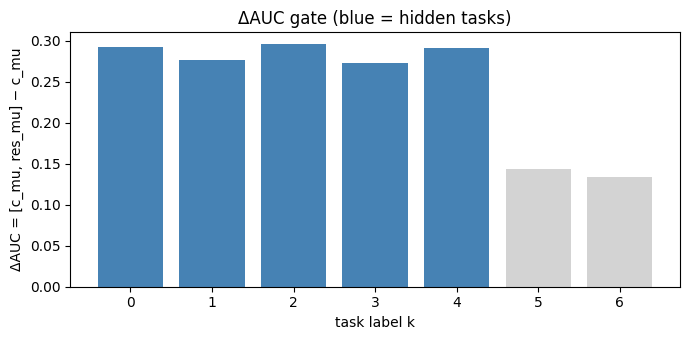

In [2096]:
y_train_all = to_numpy(train_data["y"]).astype(float)
y_test_all = to_numpy(test_data["y"]).astype(float)

gate_rows = []
for k in range(num_tasks):
    kind = "hid" if k < num_hid_tasks else "obs"
    m1 = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
    m1.fit(C_train, y_train_all[:, k])
    auc_c = roc_auc_score(y_test_all[:, k], m1.predict_proba(C_test)[:, 1])

    X2_train = np.hstack([C_train, R_train_raw])
    X2_test = np.hstack([C_test, R_test_raw])
    m2 = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
    m2.fit(X2_train, y_train_all[:, k])
    auc_cr = roc_auc_score(y_test_all[:, k], m2.predict_proba(X2_test)[:, 1])

    gate_rows.append({"task": k, "kind": kind, "auc_c_mu": auc_c,
                      "auc_c_mu_res_mu": auc_cr, "delta": auc_cr - auc_c})

gate_df = pd.DataFrame(gate_rows)
display(gate_df.round(3))

fig, ax = plt.subplots(figsize=(7, 3.5))
colors = ["steelblue" if r == "hid" else "lightgrey" for r in gate_df["kind"]]
ax.bar(gate_df["task"].astype(str), gate_df["delta"], color=colors)
ax.set_xlabel("task label k")
ax.set_ylabel("ΔAUC = [c_mu, res_mu] − c_mu")
ax.set_title("ΔAUC gate (blue = hidden tasks)")
plt.tight_layout()
plt.show()


### Task-head readout — one labeled direction per hidden task

Fit a linear probe from the residual to each hidden task label `y_k`; the decision axis is the
candidate direction for that task's hidden concept. Validation against ground truth below
(train-fit, test-scored; `raw` vs `c_mu-cleaned` ablation).

Compare results when logistic regression is trained on only original res_mu compared to res_mu cleaned of c_mu


In [2097]:
print(hid_task_idx.tolist())

[5, 14, 7, 2, 17]


variant,c_mu-cleaned,raw,ground_truth_concept
task_k,,,
0,0.870,0.817,5
1,0.874,0.815,14
2,0.879,0.819,7
3,0.867,0.812,2
4,0.870,0.807,17


raw          : mean AUC 0.814, discovered (>0.7): 5/5
c_mu-cleaned : mean AUC 0.872, discovered (>0.7): 5/5


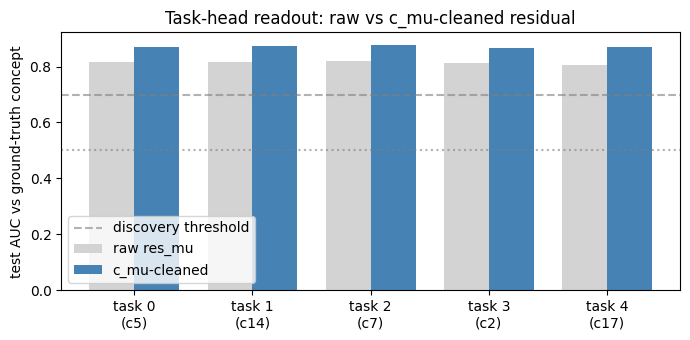

In [2098]:
readout_rows = []
readout_scores = {}
for variant, X_tr, X_te in [("raw", R_train_raw, R_test_raw),
                            ("c_mu-cleaned", R_train_cperp, R_test_cperp)]:
    # Hold test predictions for each hidden task
    scores_te = np.zeros((X_te.shape[0], num_hid_tasks))
    for k in range(num_hid_tasks):
        clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
        clf.fit(X_tr, y_train_all[:, k])
        scores_te[:, k] = clf.decision_function(X_te)
        concept = int(hid_task_idx[k])
        # AUC between predicted scores and ground-truth hidden concept labels
        auc = calculate_auc(to_numpy(test_data["hidden_residuals"])[:, concept], scores_te[:, k])
        readout_rows.append({"variant": variant, "task_k": k,
                             "ground_truth_concept": concept, "test_auc": auc})
    readout_scores[variant] = scores_te

readout_df = pd.DataFrame(readout_rows)

pivot = readout_df.pivot(index="task_k", columns="variant", values="test_auc")
pivot["ground_truth_concept"] = [int(hid_task_idx[k]) for k in pivot.index]
display(pivot.round(3))


# Plotting readout AUCs for hidden tasks, comparing raw vs c_mu-cleaned residuals
for variant in ["raw", "c_mu-cleaned"]:
    sub = readout_df[readout_df["variant"] == variant]
    print(f"{variant:13s}: mean AUC {sub['test_auc'].mean():.3f}, "
          f"discovered (>0.7): {(sub['test_auc'] > 0.7).sum()}/{num_hid_tasks}")

fig, ax = plt.subplots(figsize=(7, 3.5))
w = 0.38
xs = np.arange(num_hid_tasks)
ax.bar(xs - w / 2, pivot["raw"], w, label="raw res_mu", color="lightgrey")
ax.bar(xs + w / 2, pivot["c_mu-cleaned"], w, label="c_mu-cleaned", color="steelblue")
ax.axhline(0.7, color="grey", ls="--", alpha=0.6, label="discovery threshold")
ax.axhline(0.5, color="grey", ls=":", alpha=0.6)
ax.set_xticks(xs)
ax.set_xticklabels([f"task {k}\n(c{int(hid_task_idx[k])})" for k in xs])
ax.set_ylabel("test AUC vs ground-truth concept")
ax.set_title("Task-head readout: raw vs c_mu-cleaned residual")
ax.legend()
plt.tight_layout()
plt.show()


### Readout selectivity — each direction should peak on its own concept

Rows are all 20 ground-truth hidden concepts (task bits boxed red), columns the K readout
directions. Selective recovery = bright diagonal on task-bit rows, chance elsewhere.

Check if the residual channel ontains each concepts as a linearly accessible direction.


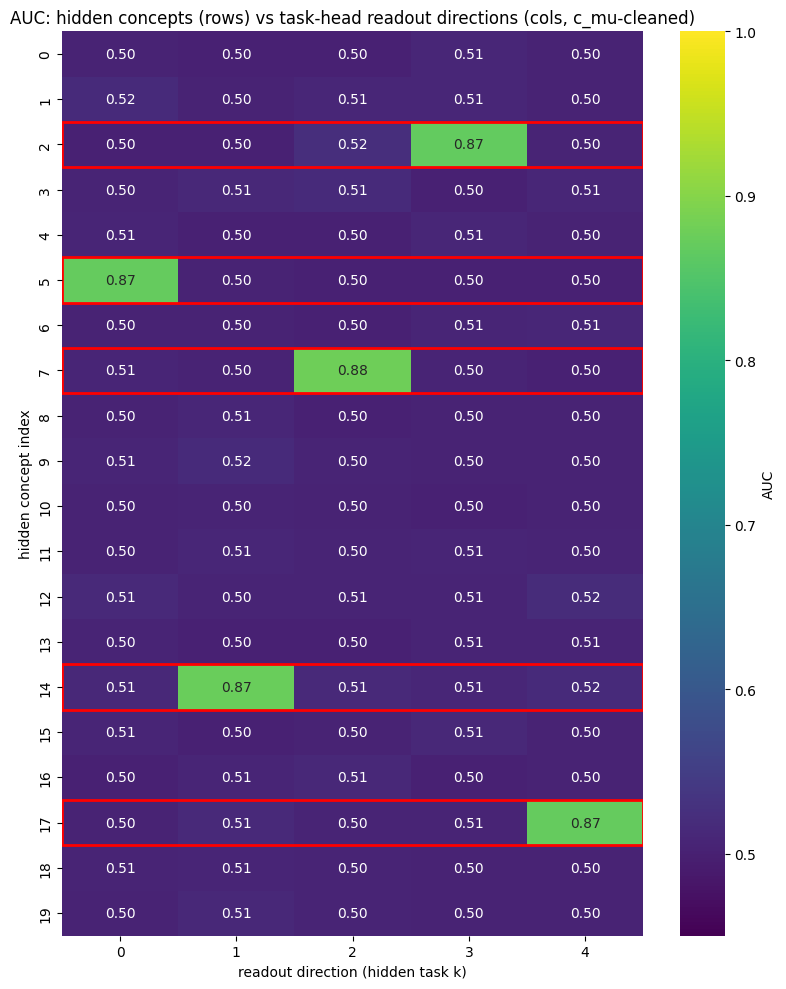

In [2099]:
readout_auc_mat = auc_matrix(
    to_numpy(test_data["hidden_residuals"]),
    readout_scores["c_mu-cleaned"],
)
plot_heatmap(
    readout_auc_mat,
    title="AUC: hidden concepts (rows) vs task-head readout directions (cols, c_mu-cleaned)",
    x_label="readout direction (hidden task k)",
    y_label="hidden concept index",
    highlight_rows=hid_task_idx.tolist(),
    annot=True,
)


### ICA on the c_mu-cleaned residual

Same ICA protocol as above, but on the non-oracle `c_mu`-cleaned residual. This rescues the
concept that raw ICA and oracle `a_c`-cleaned ICA both miss at `sigma_x=0.5` (leakage, not
background, was the blocker). Keep this as the secondary method for hidden structure *not*
tied to a known task label.


/Users/stephenmarcou/Documents/ETH Zurich/Cambridge/Code/SCBM_implementation/scbm_implementation/lib/python3.11/site-packages/sklearn/decomposition/_fastica.py:132: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


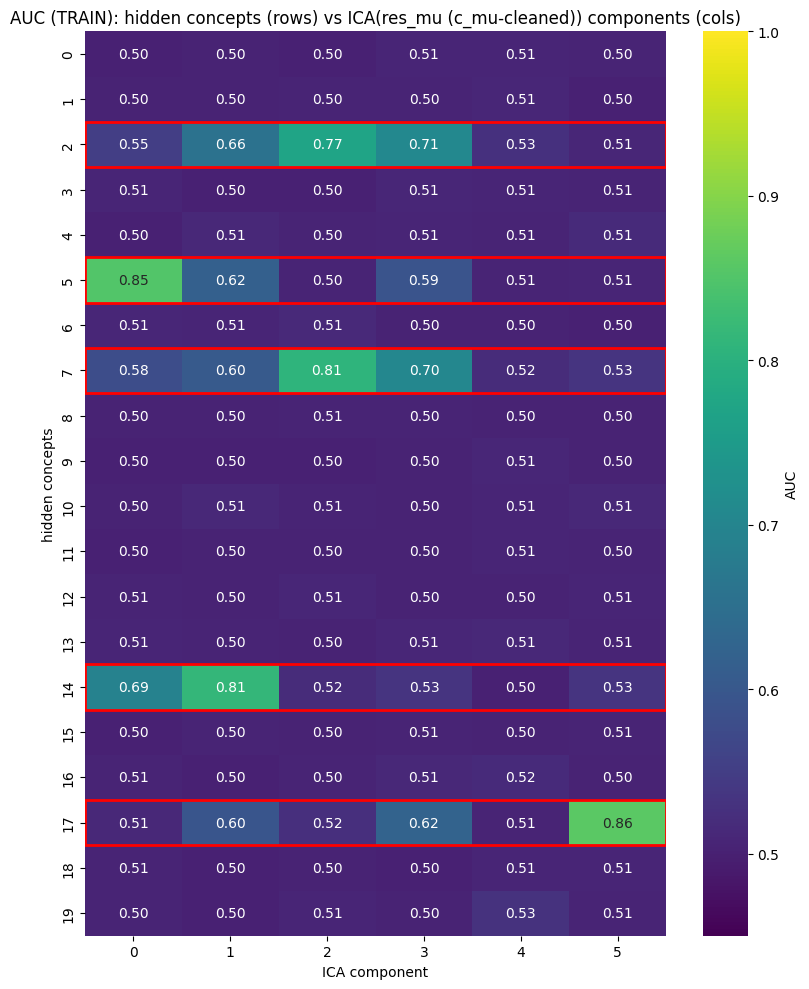

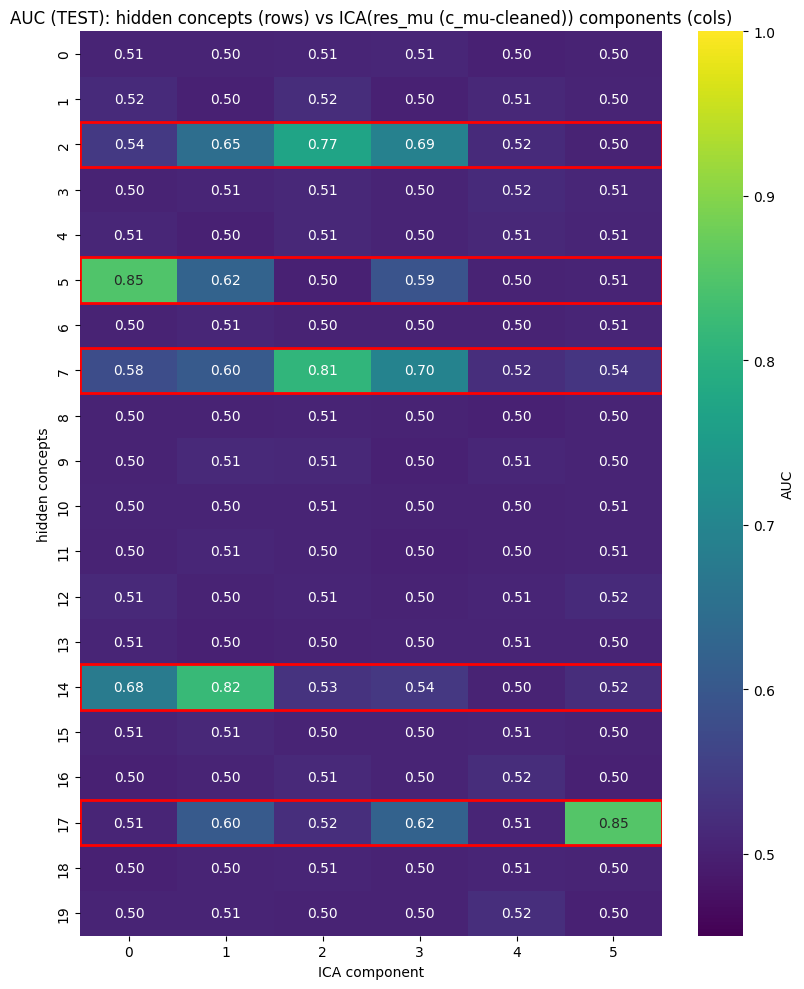

[diagnostic, test-set argmax] Best label alignment for each ICA component:


,ica_component,best_label_idx,best_auc,best_is_task_bit,best_task_k
0,0,5,0.8493,True,0.0
1,1,14,0.8202,True,1.0
2,2,7,0.8101,True,2.0
3,3,7,0.6965,True,2.0
4,4,19,0.5230,False,NaN
5,5,17,0.8522,True,4.0


[diagnostic, test-set argmax] Labels ranked by best ICA-component AUC:


,label_idx,best_ica_component,best_ica_component_auc,is_task_bit,task_k
17,17,5,0.8522,True,4.0
5,5,0,0.8493,True,0.0
14,14,1,0.8202,True,1.0
7,7,2,0.8101,True,2.0
2,2,2,0.7702,True,3.0
19,19,4,0.5230,False,NaN
16,16,4,0.5196,False,NaN
1,1,2,0.5194,False,NaN
3,3,4,0.5165,False,NaN
12,12,5,0.5159,False,NaN


[reported] One-to-one assignment fit on train, scored on test:


,label_idx,matched_component,train_auc,test_auc,is_task_bit,task_k,discovered
4,17,5,0.8585,0.8522,True,4.0,True
1,5,0,0.8498,0.8493,True,0.0,True
3,14,1,0.8145,0.8202,True,1.0,True
2,7,2,0.8080,0.8101,True,2.0,True
0,2,3,0.7062,0.6898,True,3.0,False
5,19,4,0.5275,0.5230,False,NaN,False


Mean test AUC by task-bit status:
is_task_bit
False    0.5230
True     0.8043
Name: test_auc, dtype: float64
Task-bit labels discovered (test AUC > 0.7): 4 / 5


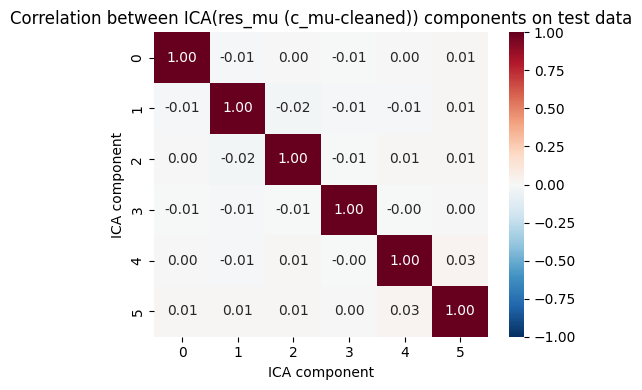

ICA components fitted: 6
Mean absolute off-diagonal ICA component correlation: 0.0096


In [2100]:
run_ica_analysis(
    R_train_cperp,
    R_test_cperp,
    true_train_labels=train_data["hidden_residuals"],
    true_test_labels=test_data["hidden_residuals"],
    n_components=min(num_hid_tasks + 1, R_train_cperp.shape[1]),
    name="res_mu (c_mu-cleaned)",
    label_name="hidden concepts",
    highlight_rows=hid_task_idx.tolist(),
    task_map=task_map_hid,
    assignment_threshold=0.7,
);


## Heatmap hidden concepts and clean res_mu

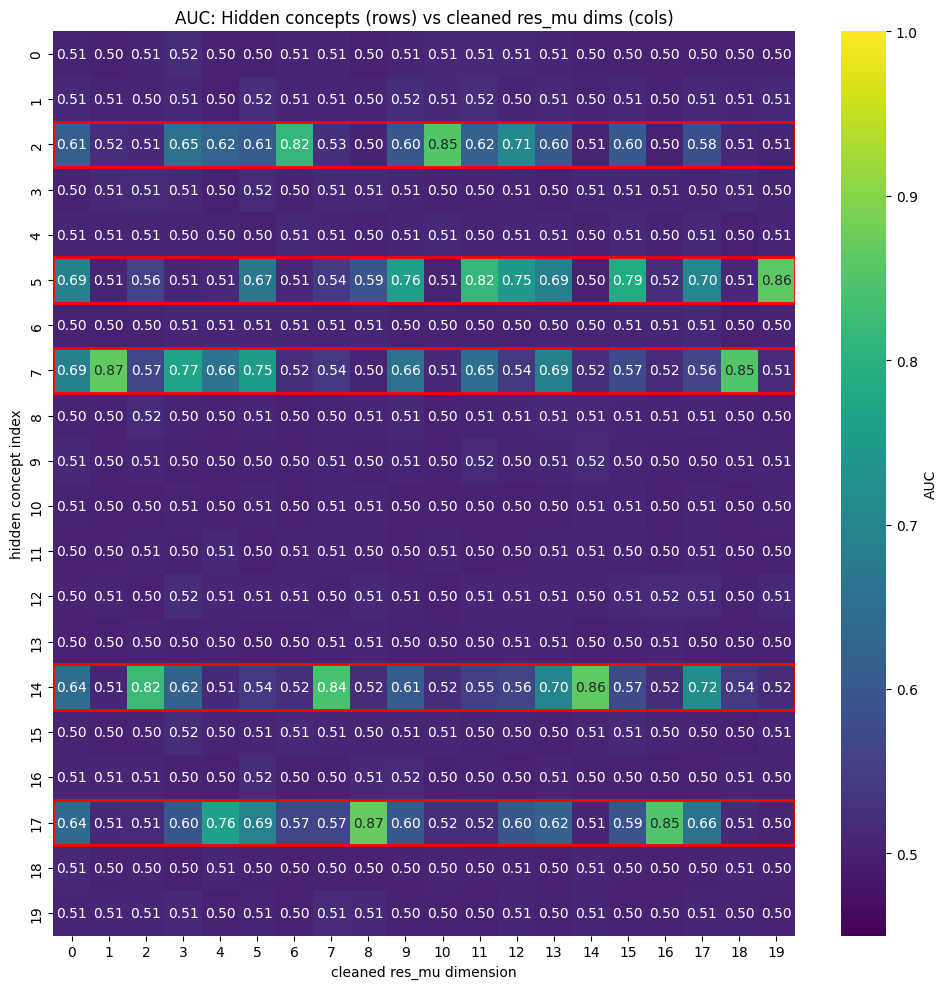

In [2101]:
auc = auc_matrix(to_numpy(test_data["hidden_residuals"]), R_test_cperp)
plot_heatmap(
    auc,
    title="AUC: Hidden concepts (rows) vs cleaned res_mu dims (cols)",
    x_label="cleaned res_mu dimension",
    y_label="hidden concept index",
    highlight_rows=hid_task_idx.tolist(),
    annot=True,
)